# Package Imports

In [210]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, normalize)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import permutation_test_score
from sklearn.decomposition import PCA


pd.set_option("display.max_columns", None)

seed = 42

In [34]:
current_path = os.path.abspath(os.getcwd())

# Find the index of 'slpt' in the path and keep everything up to and including 'slpt'
if "slpt" in current_path:
  base_path = current_path[:current_path.index("slpt") + len("slpt")]
else:
  base_path = current_path

# print(base_path) # ensure slpt is the last part of the path

def get_path(*args):
    """
    Returns the absolute path to a file or directory relative to the base path.
    """
    return os.path.join(base_path, *args)


# Data Import

In [35]:
data_raw = pd.read_csv(get_path("data/raw/cell2celltrain.csv"))
data_raw.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [36]:
data_raw.tail()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.3,2.7,48.3,0.0,0.0,58.9,17.0,1.3,160.3,33.3,12.0,0.0,0.3,29,1,1,LAXSFN818,2.0,2.0,526.0,68.0,64.0,No,Yes,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,16.7,0.7,41.3,0.0,0.0,681.5,89.7,33.3,318.7,248.3,17.3,0.0,14.3,29,1,1,LAXCDG310,2.0,2.0,464.0,48.0,48.0,Yes,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.7,4.3,287.0,1.3,13.7,1225.3,430.3,87.7,1359.0,910.3,76.0,0.0,6.7,25,1,1,LAXCDG310,3.0,2.0,378.0,36.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,1,1,NEVPOW619,2.0,2.0,433.0,32.0,0.0,Yes,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,9,No,0,30,No,5-Low,Other,Other,No
51046,3399994,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.7,0.7,117.3,1.3,1.0,330.9,55.0,16.7,442.3,167.3,19.3,0.0,0.0,25,1,1,NEVPOW619,7.0,5.0,75.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,2,1,No,No,0,0,No,1,60,Yes,5-Low,Other,Other,Unknown


In [37]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

# Joining Data

In [38]:
# Strip the labels from credit rating and create a csv for lookup
data_raw[['CreditRatingNum', 'CreditRatingLabel']] = data_raw['CreditRating'].str.extract(r'(\d)-(.+)')
data_raw['CreditRatingNum'] = data_raw['CreditRatingNum'].astype(int)
credit_rating_lookup = data_raw[['CreditRatingNum', 'CreditRatingLabel']].drop_duplicates()
credit_rating_lookup.to_csv(get_path("data/raw/credit_rating_lookup.csv"), index=False)
data_raw = data_raw.drop(columns=['CreditRating', 'CreditRatingLabel'])

In [39]:
# Join the main data with lookup table
lookup = pd.read_csv(get_path("data/raw/credit_rating_lookup.csv"))
lookup['CreditRatingNum'] = lookup['CreditRatingNum'].astype(int)
data_joined = data_raw.merge(lookup, on='CreditRatingNum', how='left')

data_joined.head()


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest


# Cleaning Data

In [40]:
# Check for missing values in columns
missing = data_joined.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

AgeHH1                   909
AgeHH2                   909
PercChangeMinutes        367
PercChangeRevenues       367
MonthlyRevenue           156
MonthlyMinutes           156
TotalRecurringCharge     156
DirectorAssistedCalls    156
OverageMinutes           156
RoamingCalls             156
ServiceArea               24
Handsets                   1
HandsetModels              1
CurrentEquipmentDays       1
dtype: int64

In [41]:
data_joined.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest


In [42]:
data_joined.tail()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.3,2.7,48.3,0.0,0.0,58.9,17.0,1.3,160.3,33.3,12.0,0.0,0.3,29,1,1,LAXSFN818,2.0,2.0,526.0,68.0,64.0,No,Yes,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,0,60,No,Suburban,Other,Yes,1,Highest
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,16.7,0.7,41.3,0.0,0.0,681.5,89.7,33.3,318.7,248.3,17.3,0.0,14.3,29,1,1,LAXCDG310,2.0,2.0,464.0,48.0,48.0,Yes,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,9,No,1,60,No,Other,Other,No,3,Good
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.7,4.3,287.0,1.3,13.7,1225.3,430.3,87.7,1359.0,910.3,76.0,0.0,6.7,25,1,1,LAXCDG310,3.0,2.0,378.0,36.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,7,No,1,80,No,Other,Clerical,No,5,Low
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,1,1,NEVPOW619,2.0,2.0,433.0,32.0,0.0,Yes,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,9,No,0,30,No,Other,Other,No,5,Low
51046,3399994,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.7,0.7,117.3,1.3,1.0,330.9,55.0,16.7,442.3,167.3,19.3,0.0,0.0,25,1,1,NEVPOW619,7.0,5.0,75.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,2,1,No,No,0,0,No,1,60,Yes,Other,Other,Unknown,5,Low


In [43]:
data_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [44]:
#Drop AgeHH1 and AgeHH2 due to missing values
data_joined.drop(columns=["AgeHH1", "AgeHH2"], inplace=True)

#Fill missing values in crtical columns with average values

usage_cols = ["MonthlyRevenue", "MonthlyMinutes", "TotalRecurringCharge", "DirectorAssistedCalls", "OverageMinutes", "RoamingCalls"]
for col in usage_cols:
    data_joined[col].fillna(data_joined[col].median(), inplace=True)

#Fill missing new & inactive customer data with 0
data_joined["PercChangeMinutes"].fillna(0, inplace=True)
data_joined["PercChangeRevenues"].fillna(0, inplace=True)

#Fill other missing data
data_joined["ServiceArea"].fillna(data_joined["ServiceArea"].mode()[0], inplace=True)
data_joined["Handsets"].fillna(data_joined["Handsets"].median(), inplace=True)
data_joined["HandsetModels"].fillna(data_joined["HandsetModels"].median(), inplace=True)
data_joined["CurrentEquipmentDays"].fillna(data_joined["CurrentEquipmentDays"].median(), inplace=True)

# Descriptive Statistics

In [45]:
numeric_cols = data_joined.select_dtypes(include='number')
if 'CustomerID' in numeric_cols.columns:
    numeric_cols = numeric_cols.drop(columns=['CustomerID'])
numeric_cols.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,CreditRatingNum
count,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,58.802788,525.165514,46.824495,0.893257,39.914628,1.232466,-11.464885,-1.183415,6.011489,4.085672,28.288981,1.868999,0.298838,114.800121,25.377715,8.178104,90.549515,67.650790,10.158003,0.012277,1.840504,18.756264,1.532157,1.354340,1.805630,1.558740,380.544831,0.037201,0.018277,0.052070,4.324524,0.053911,2.886967
std,44.442964,529.134170,23.812615,2.225423,96.462028,9.803517,256.589244,39.432523,9.043955,10.946905,38.876194,5.096138,1.168277,166.485896,35.209147,16.665878,104.947470,92.752699,15.555284,0.594168,5.585129,9.800138,1.223384,0.675477,1.331165,0.905927,253.799599,0.206483,0.142458,0.307592,3.138236,0.383147,1.583360
min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,0.700000,0.000000,5.300000,0.000000,0.000000,8.300000,3.300000,0.000000,23.000000,11.000000,1.700000,0.000000,0.000000,11.000000,1.000000,1.000000,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-4.000000,-0.300000,3.000000,1.000000,16.300000,0.000000,0.000000,52.800000,13.700000,2.000000,62.000000,35.700000,5.300000,0.000000,0.300000,16.000000,1.000000,1.000000,1.000000,1.000000,329.000000,0.000000,0.000000,0.000000,5.000000,0.000000,2.000000
75%,70.960000,722.000000,60.000000,0.990000,40.000000,0.200000,65.000000,1.550000,7.700000,3.700000,36.300000,1.700000,0.300000,153.500000,34.000000,9.300000,121.300000,88.700000,12.300000,0.000000,1.300000,24.000000,2.000000,2.000000,2.000000,2.000000,515.000000,0.000000,0.000000,0.000000,7.000000,0.000000,4.000000
max,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,384.300000,848.700000,327.300000,66.000000,2692.400000,644.300000,519.300000,2090.700000,1474.700000,411.700000,81.300000,212.700000,61.000000,196.000000,53.000000,24.000000,15.000000,1812.000000,4.000000,3.000000,35.000000,9.000000,25.000000,7.000000


# Visualisations

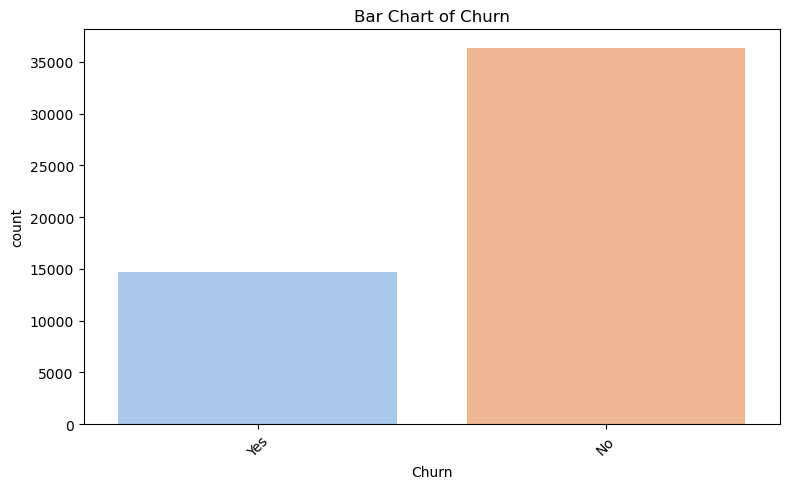

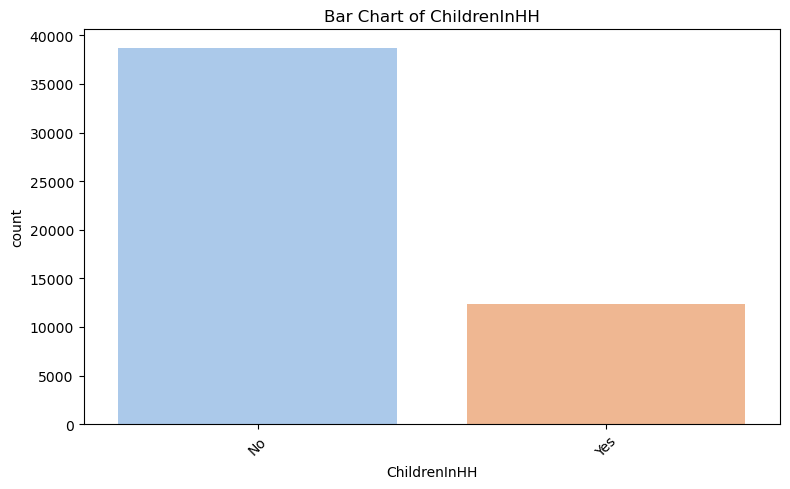

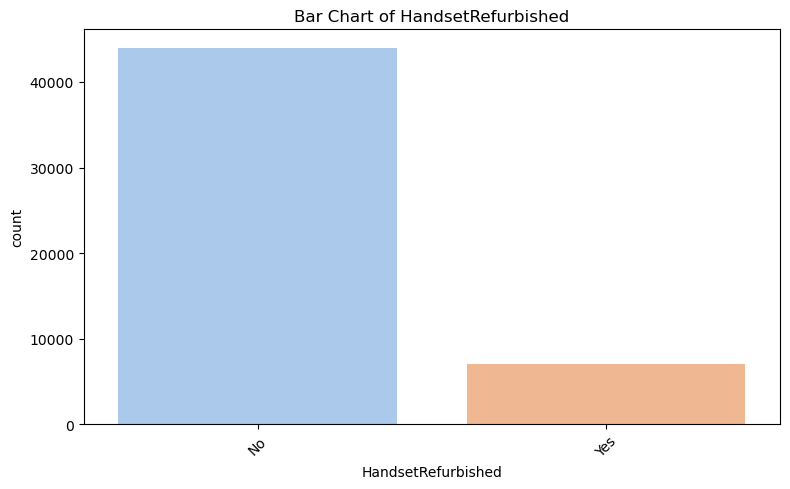

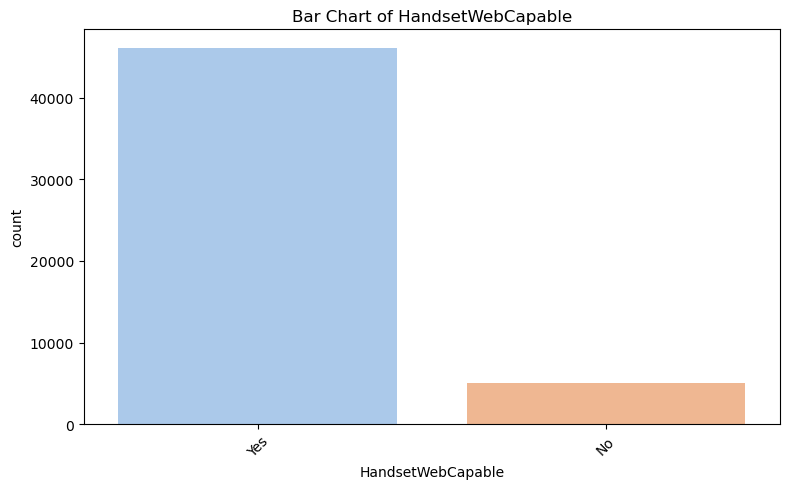

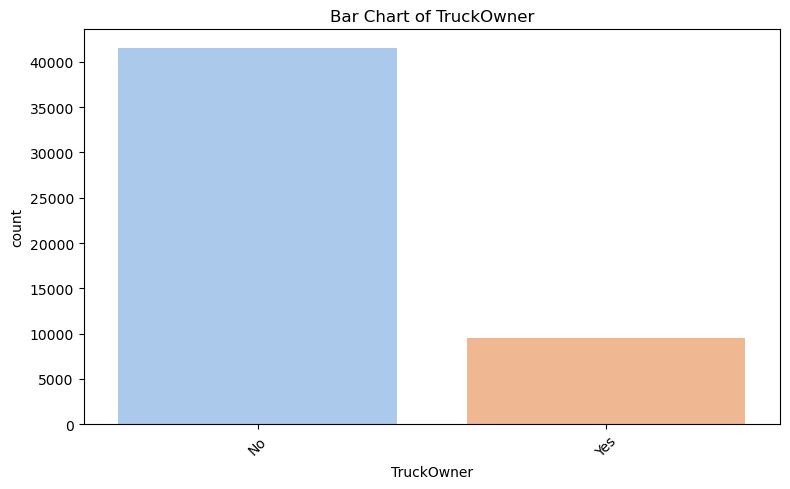

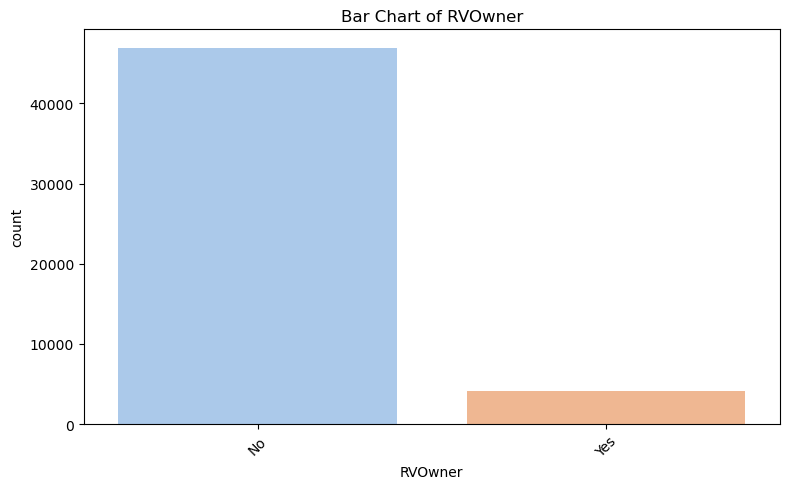

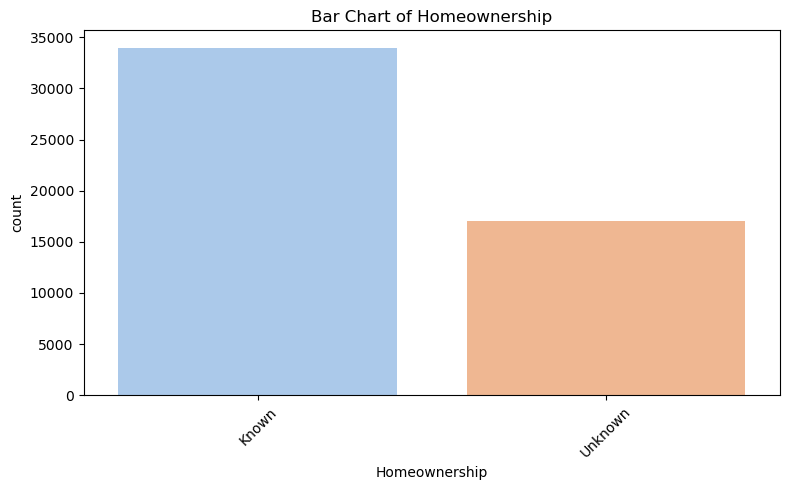

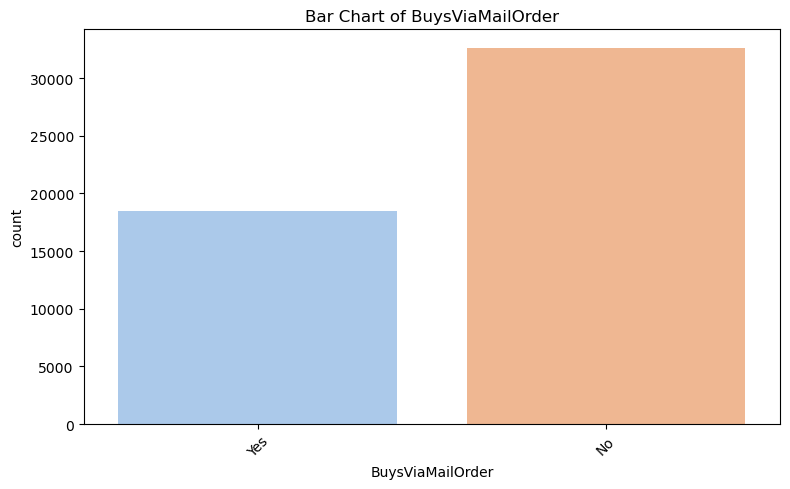

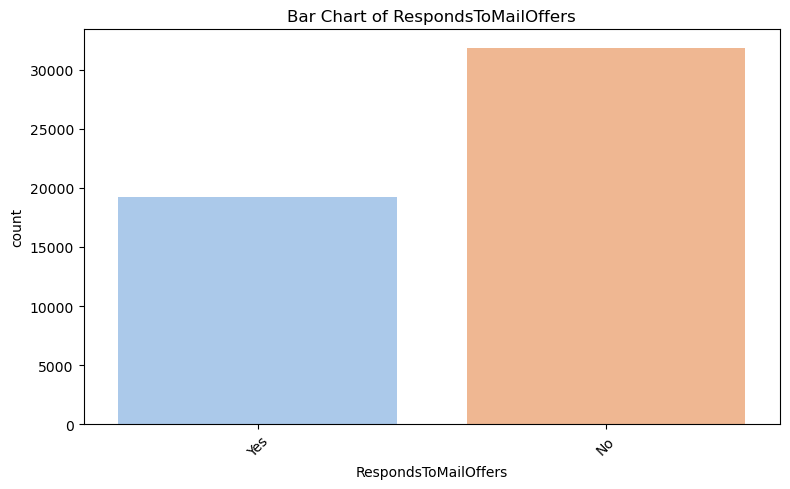

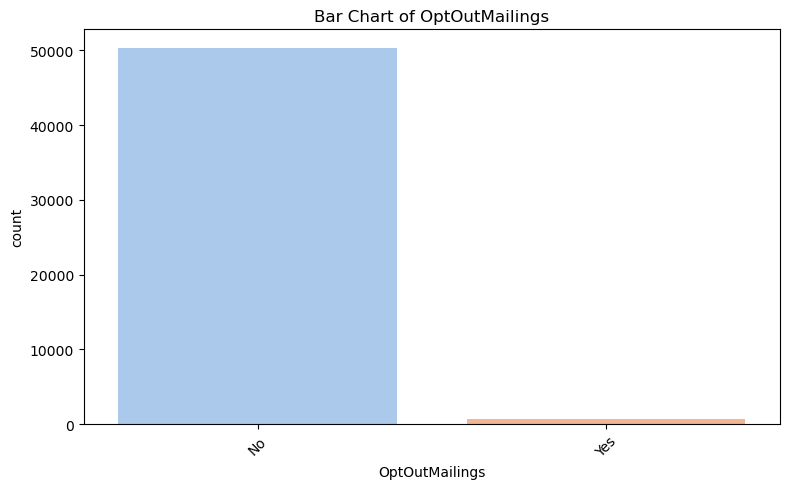

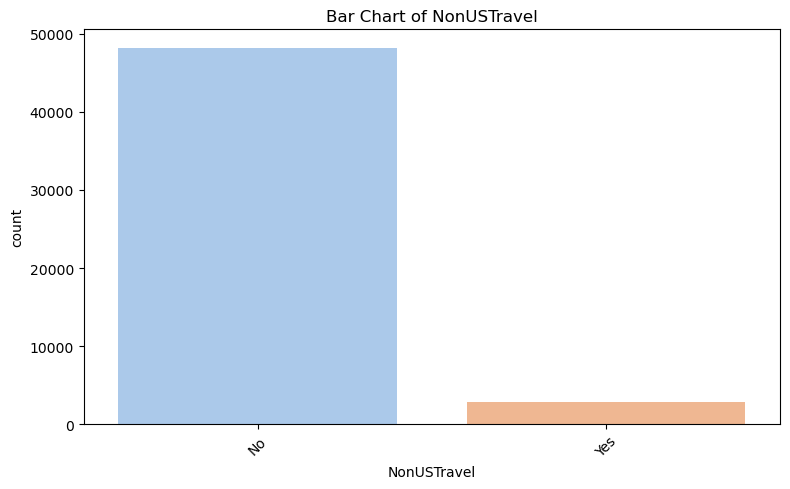

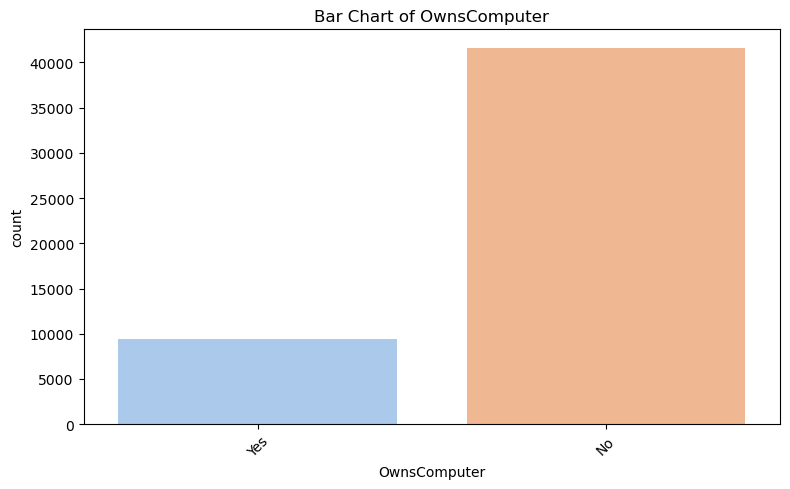

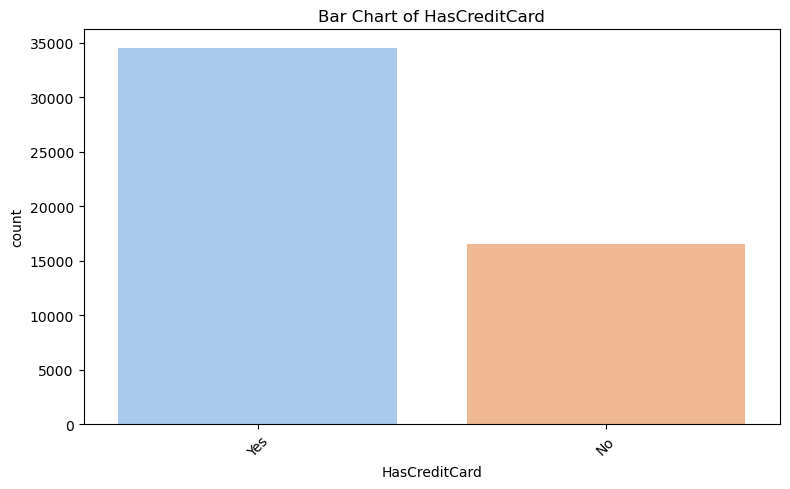

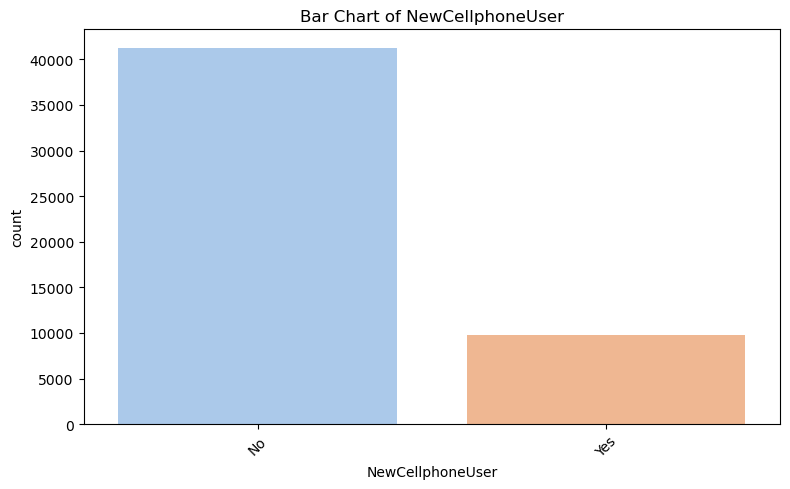

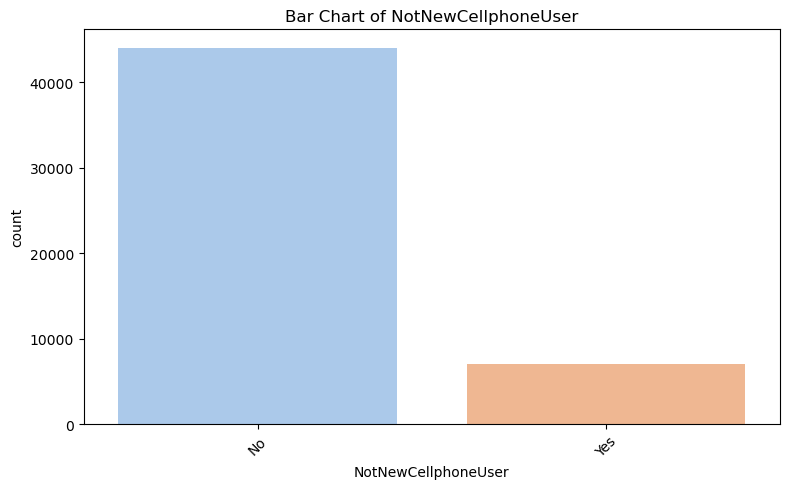

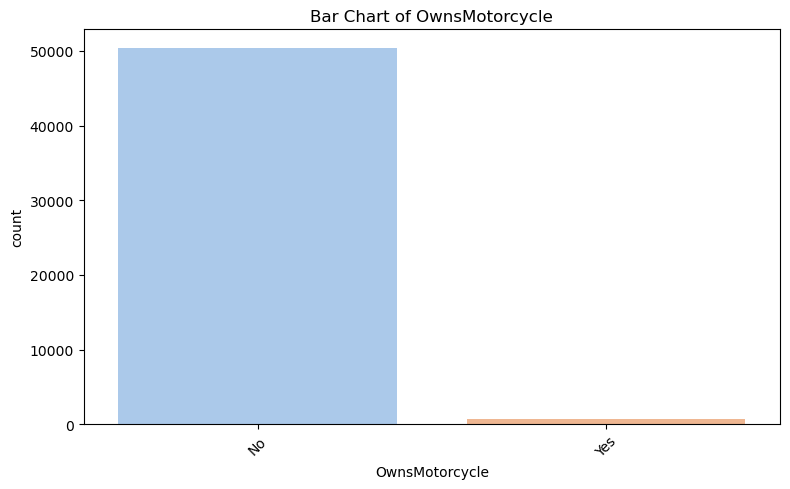

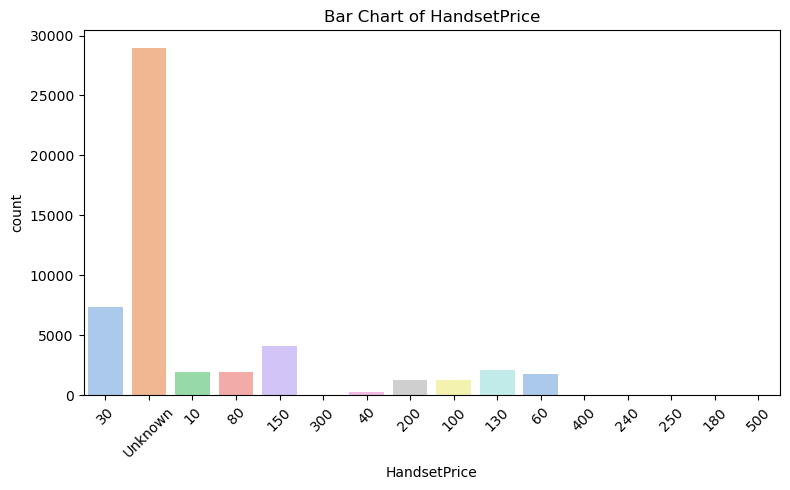

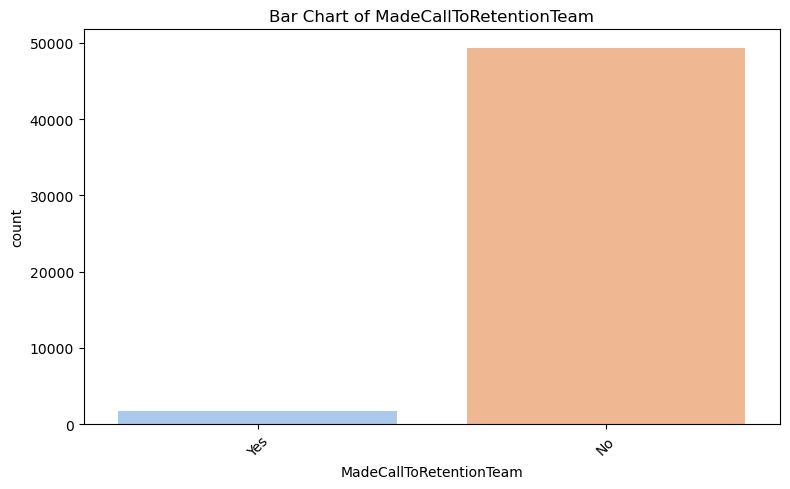

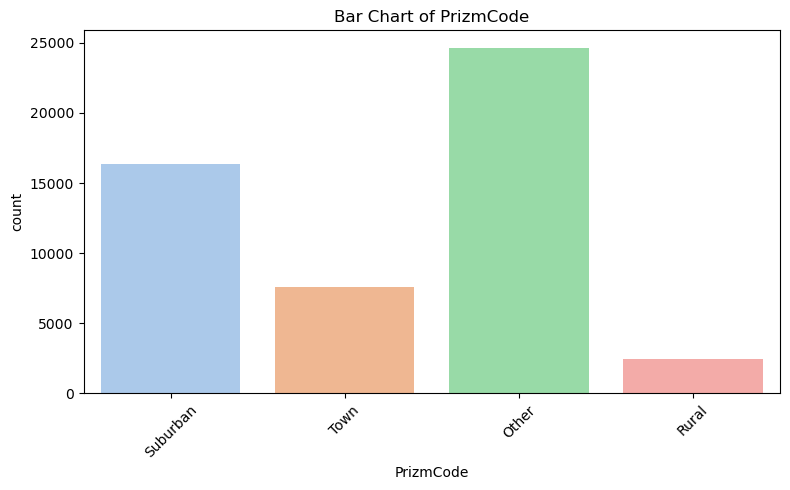

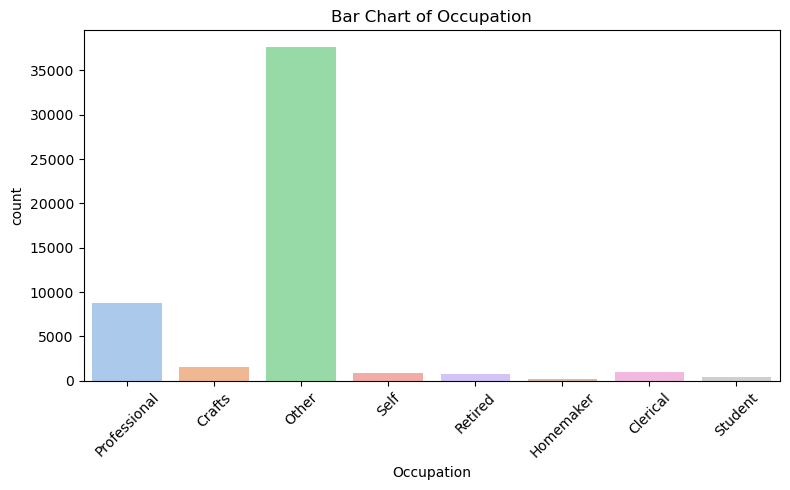

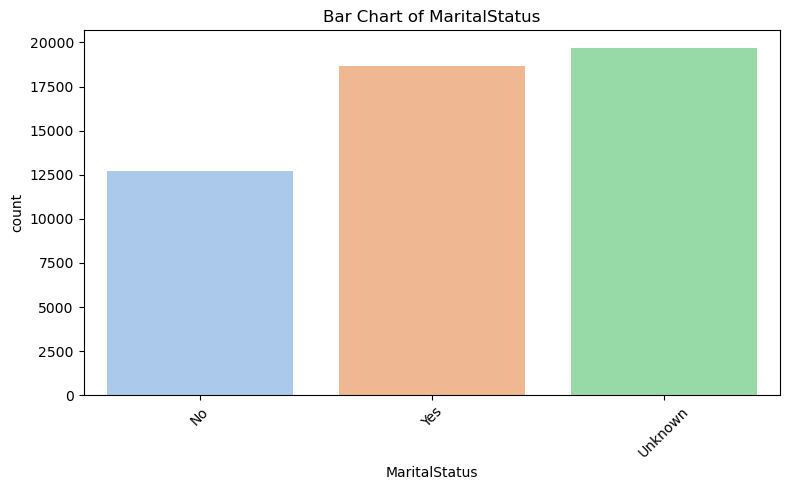

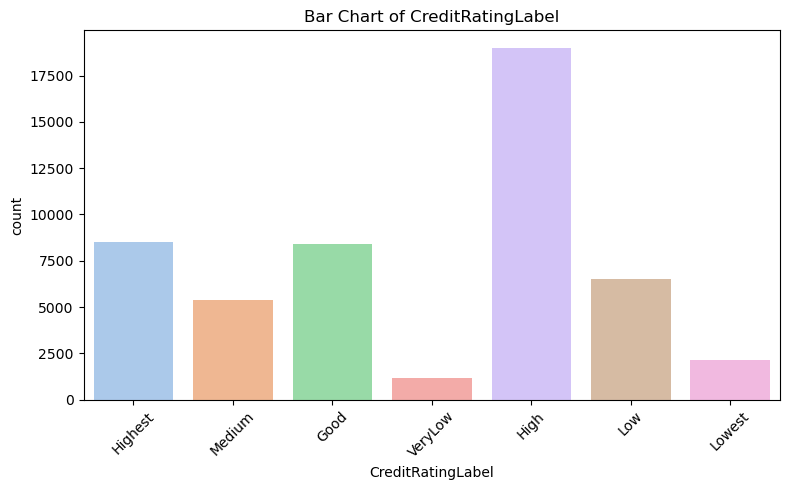

In [46]:
# Select only categorical columns (object or category types)
cat_cols = data_joined.select_dtypes(include=['object', 'category'])
if 'ServiceArea' in cat_cols.columns:
    cat_cols = cat_cols.drop(columns=['ServiceArea'])
# Plot bar charts for each categorical column
for col in cat_cols.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data_joined, x=col, palette='pastel')
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)  # Rotate labels if needed
    plt.tight_layout()
    plt.show()

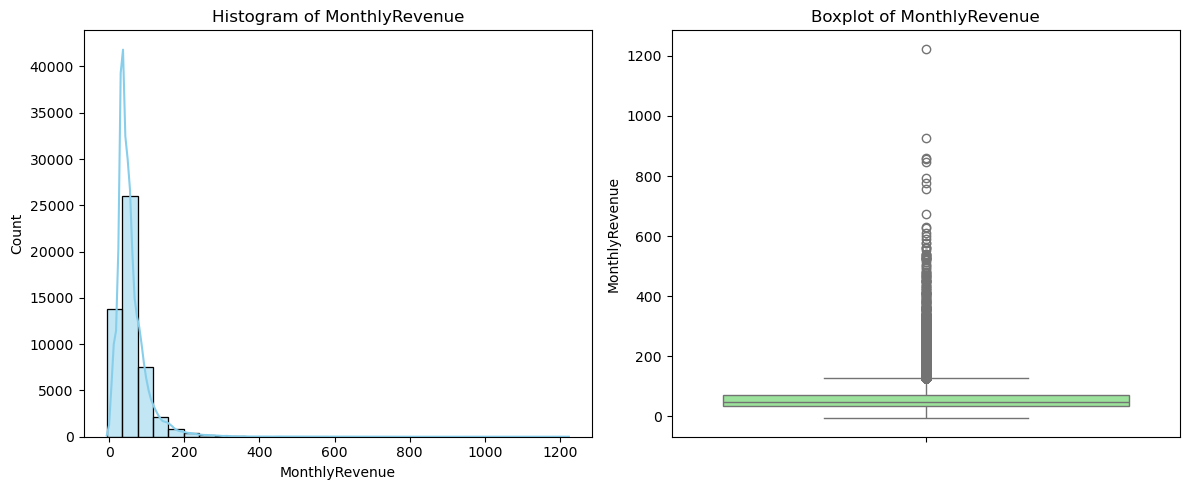

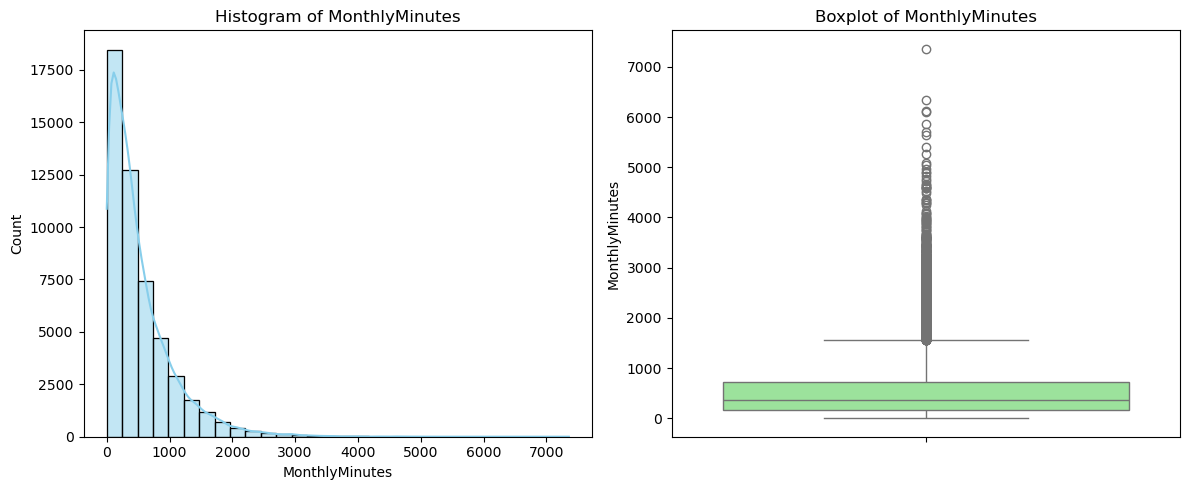

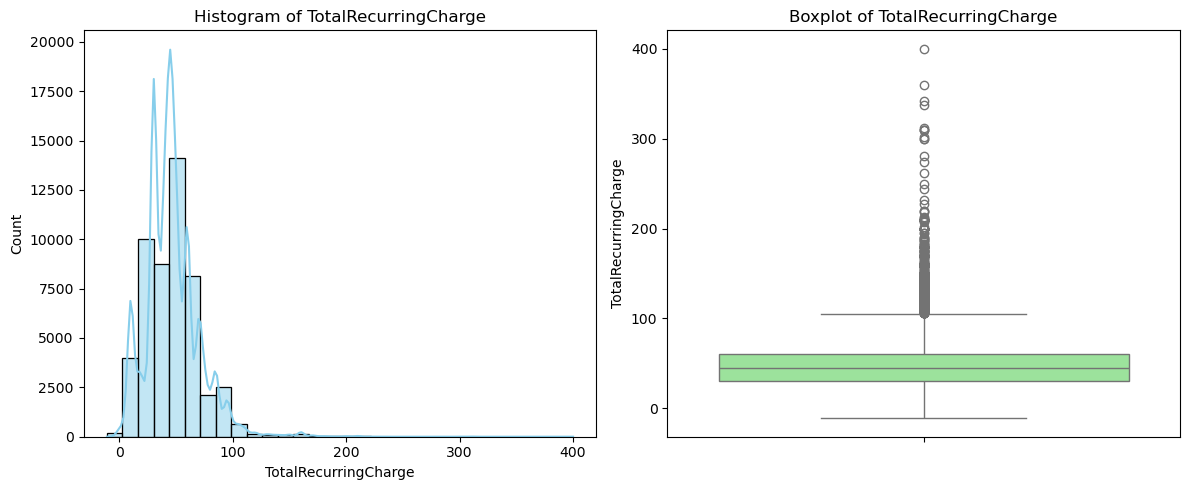

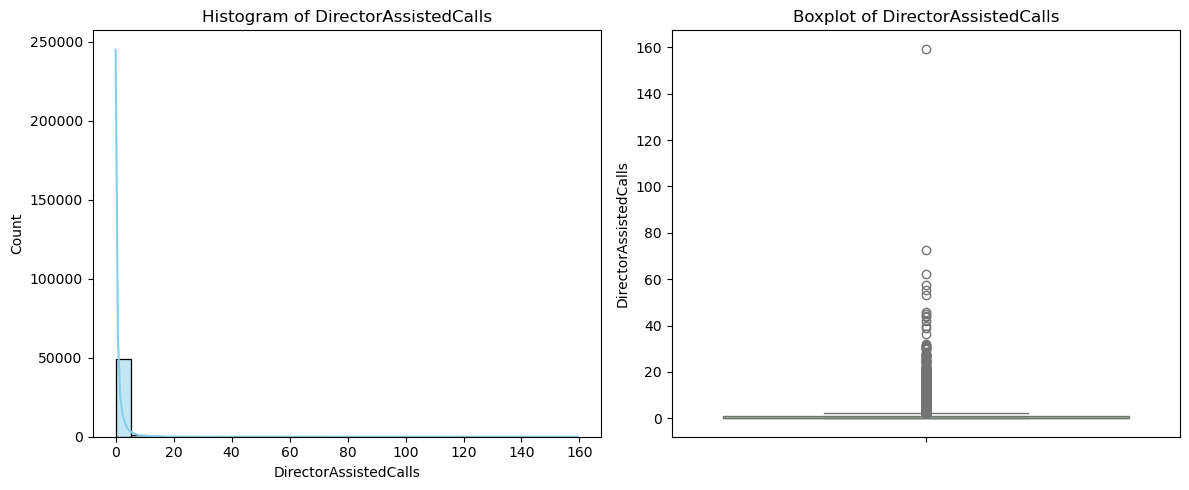

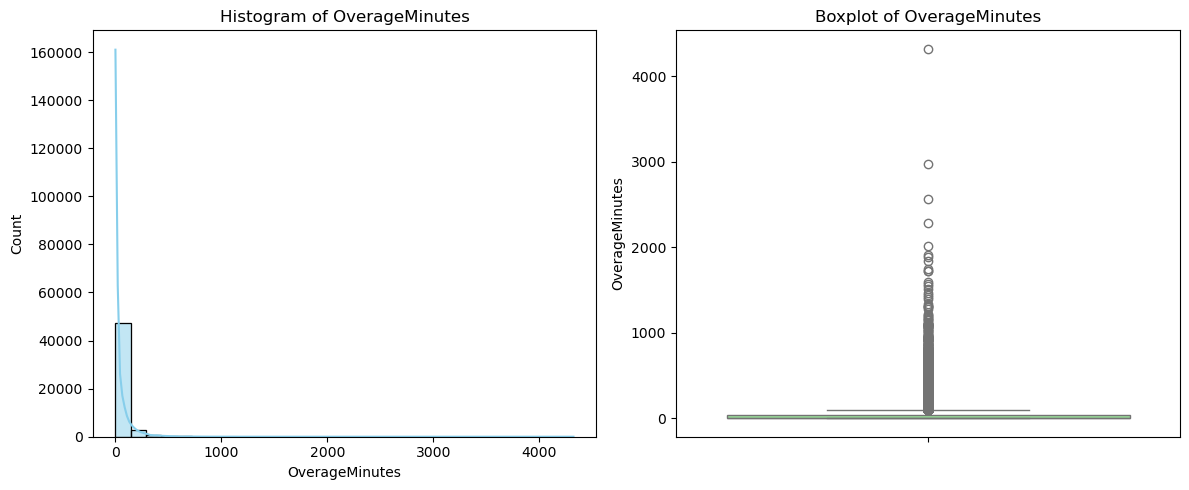

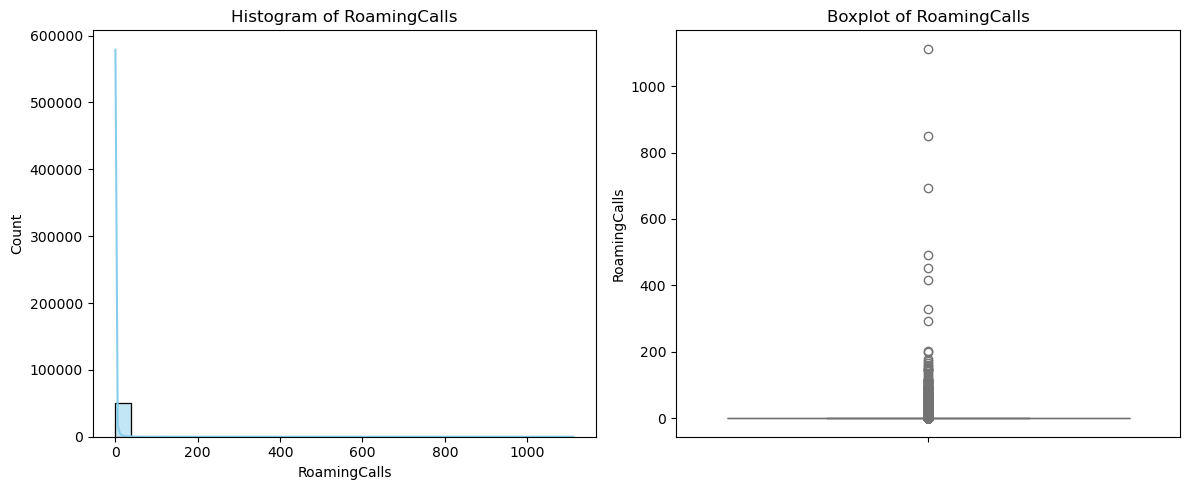

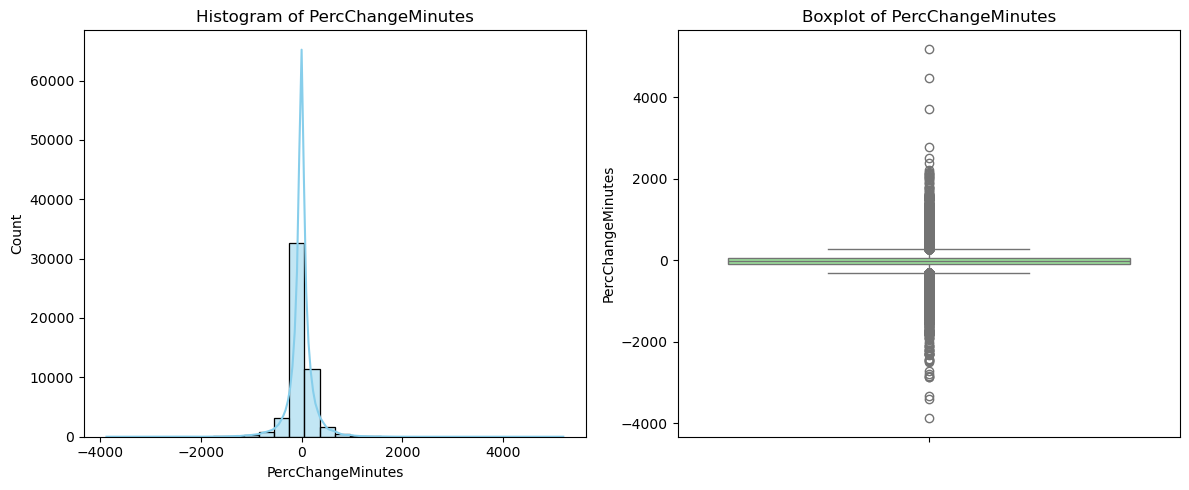

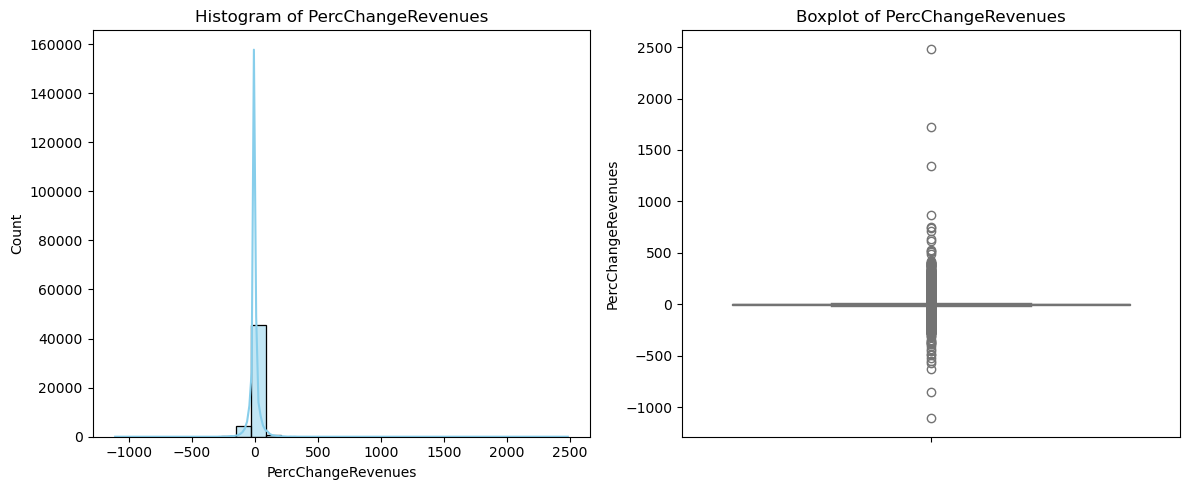

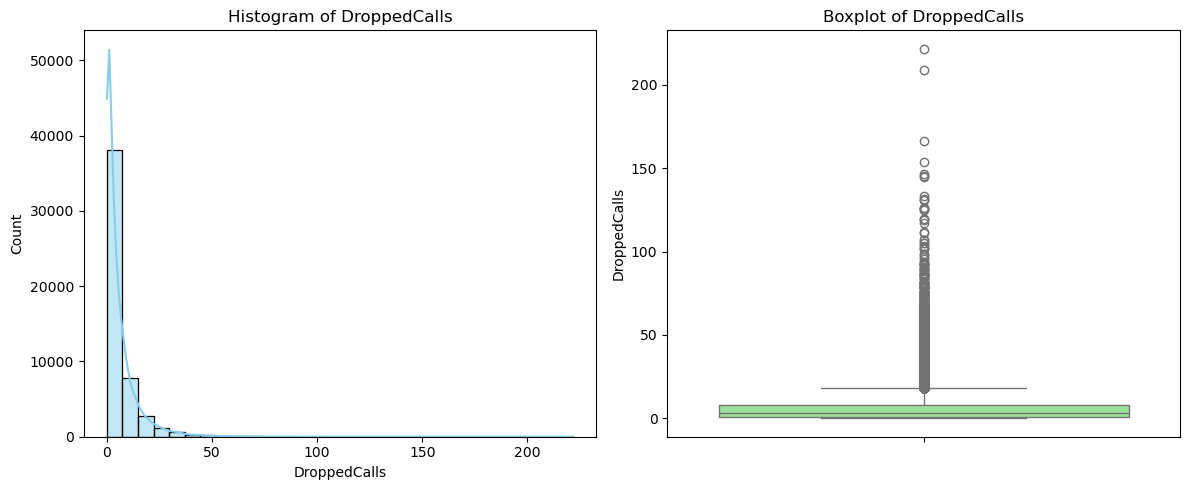

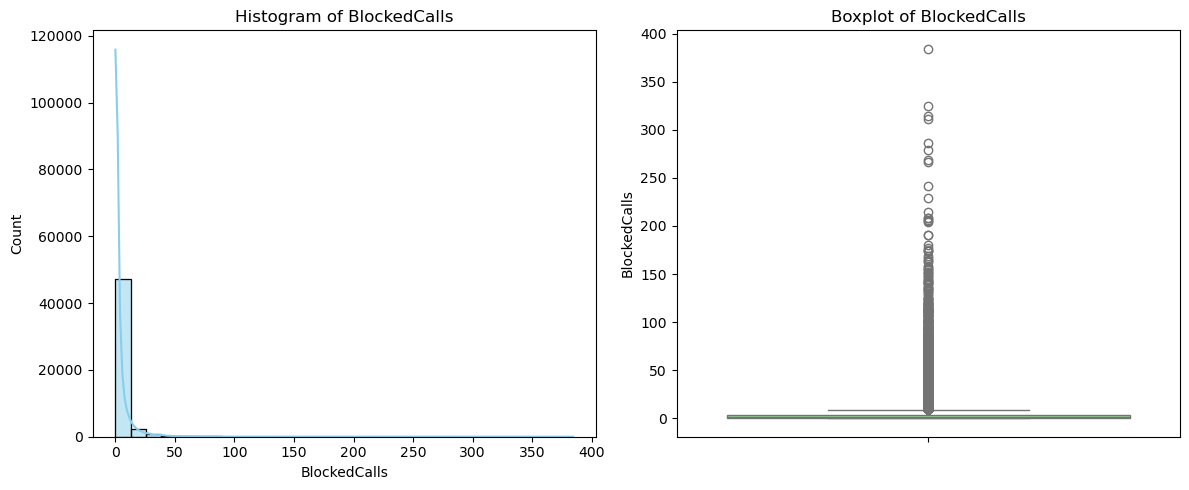

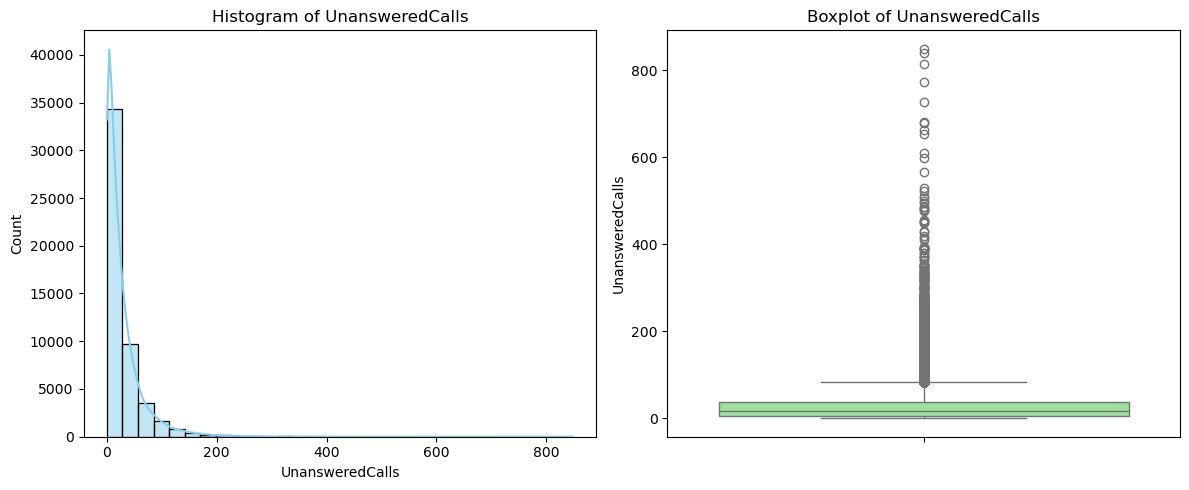

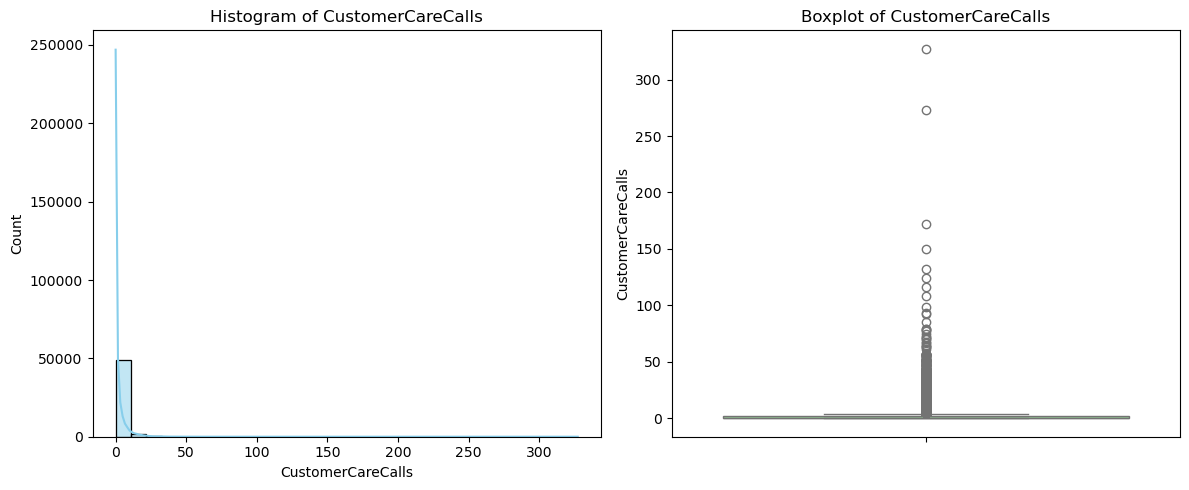

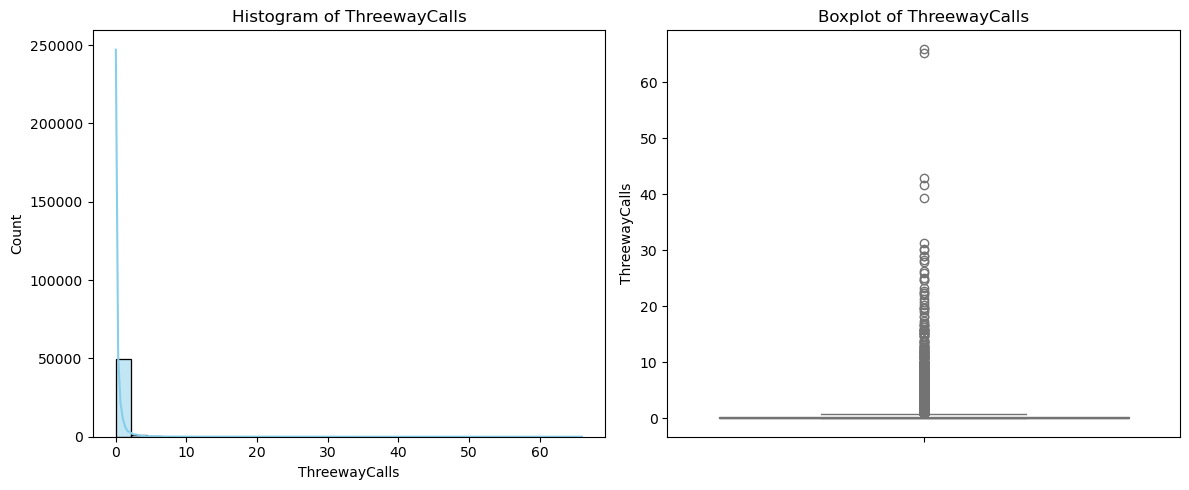

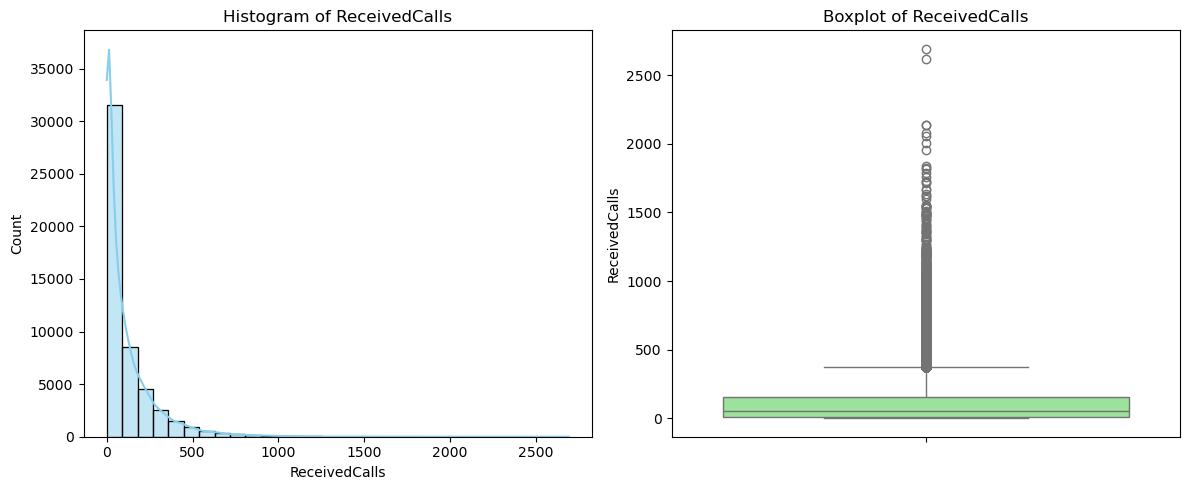

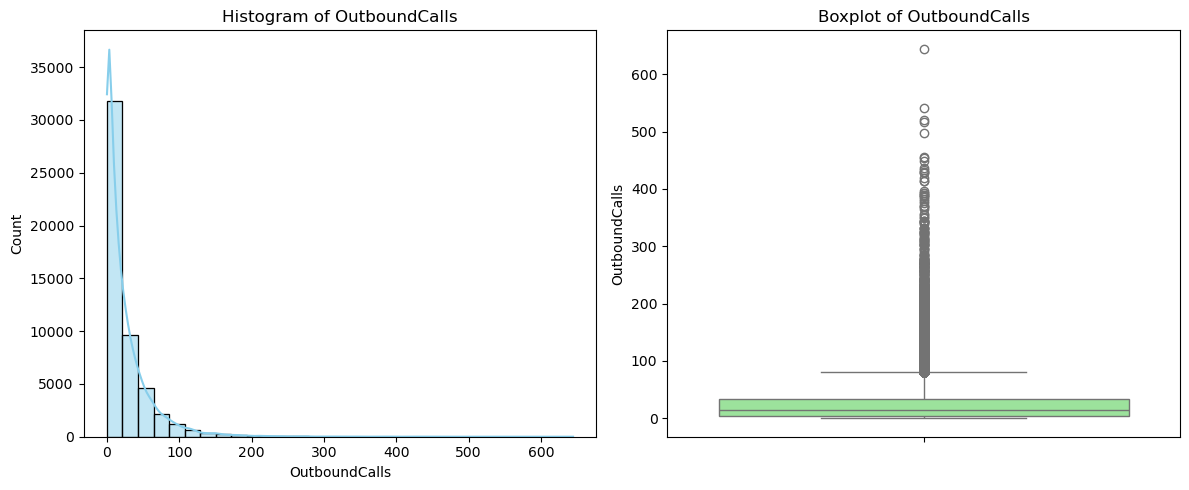

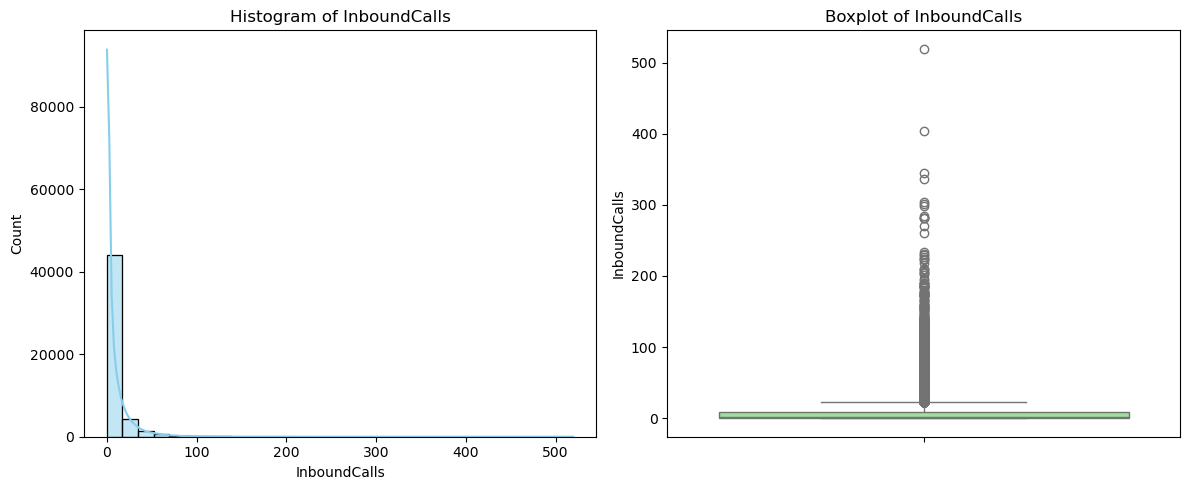

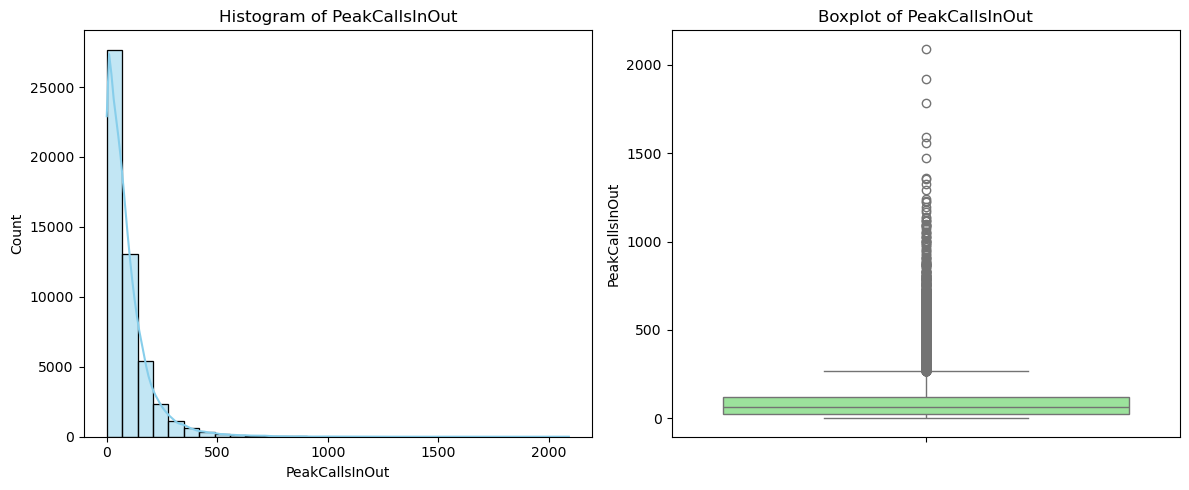

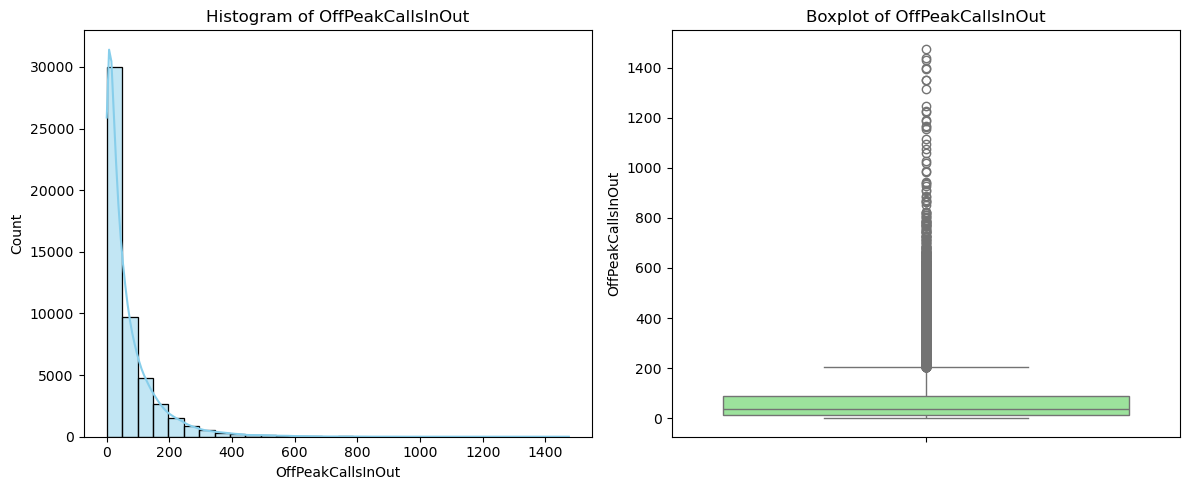

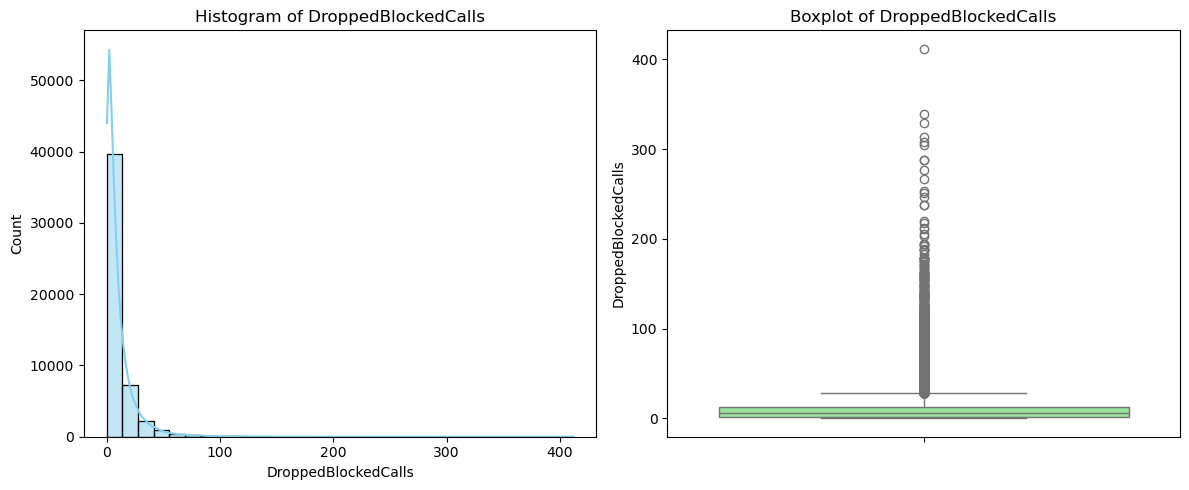

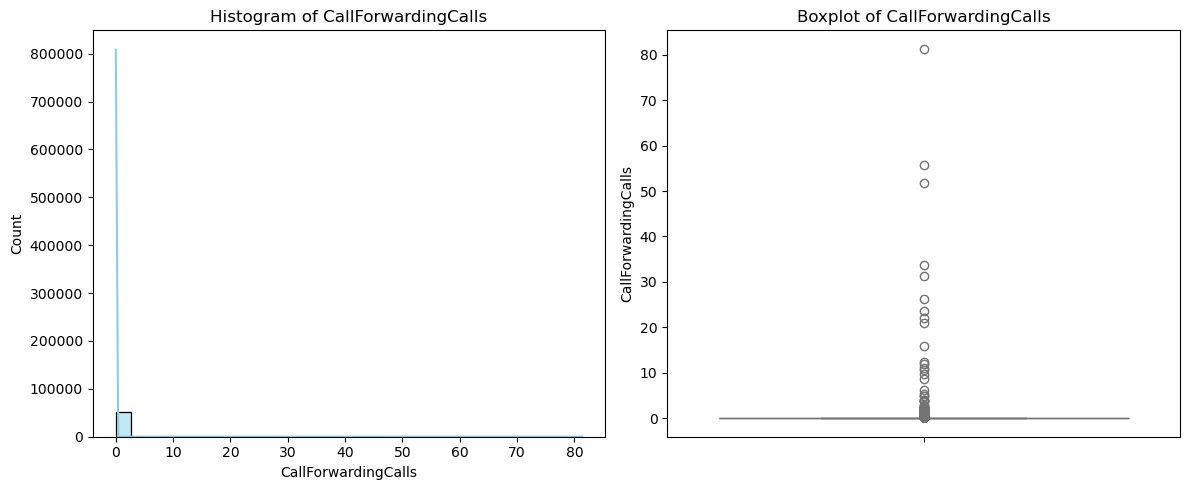

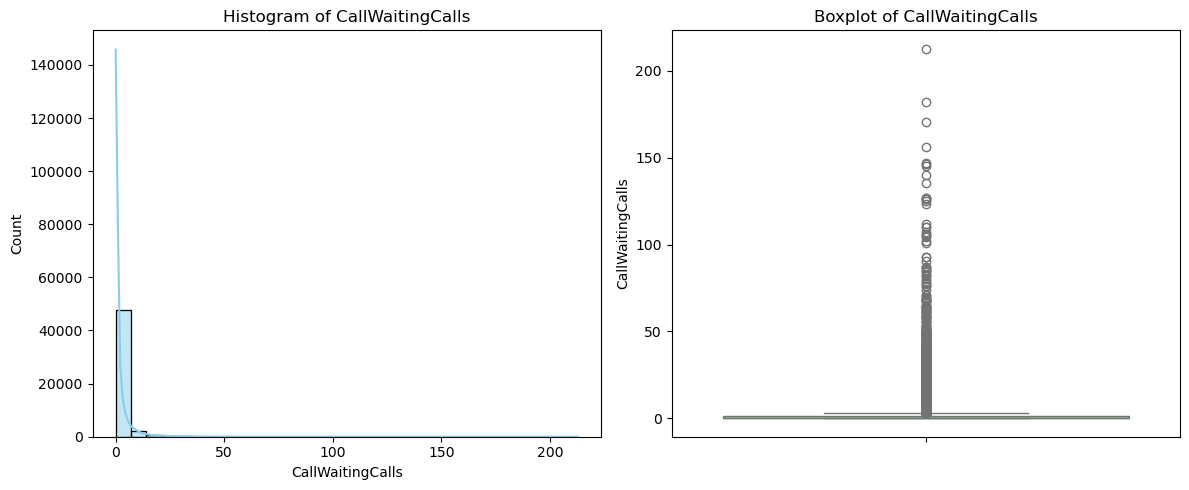

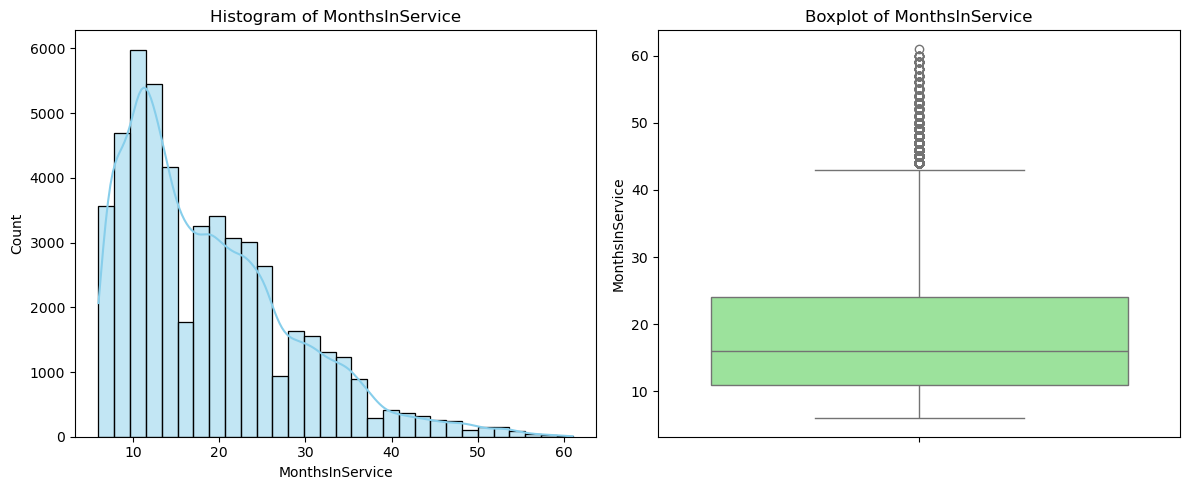

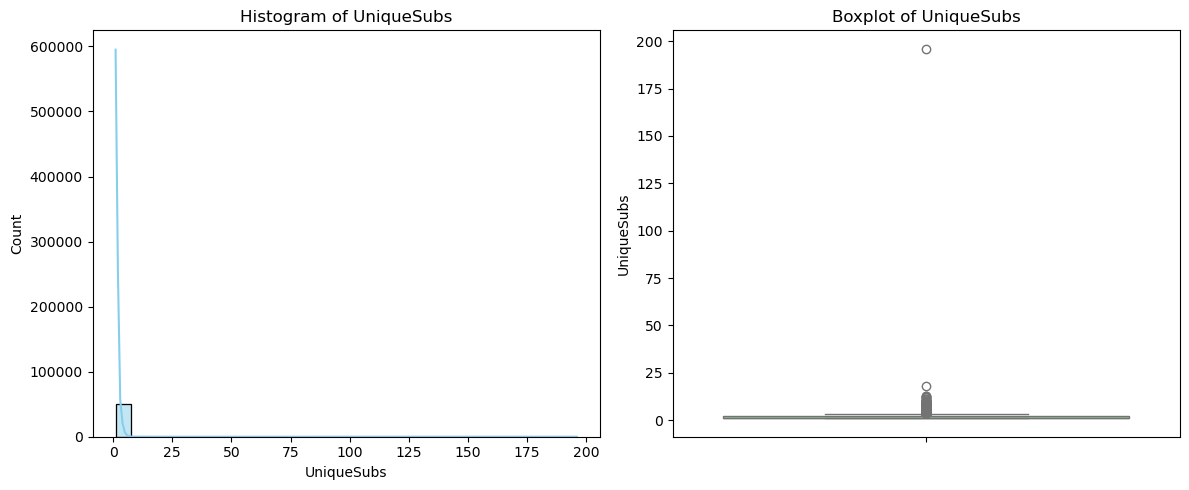

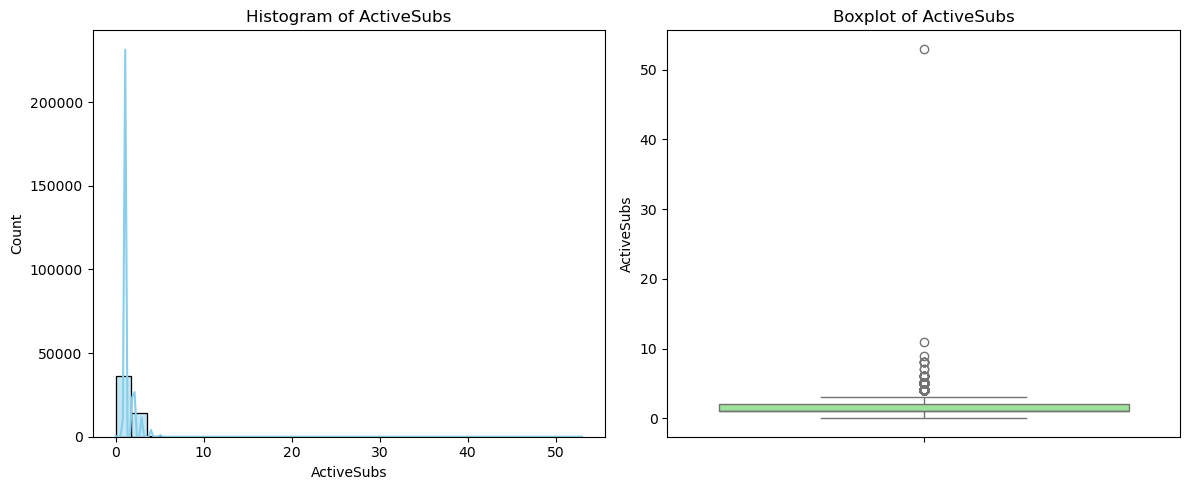

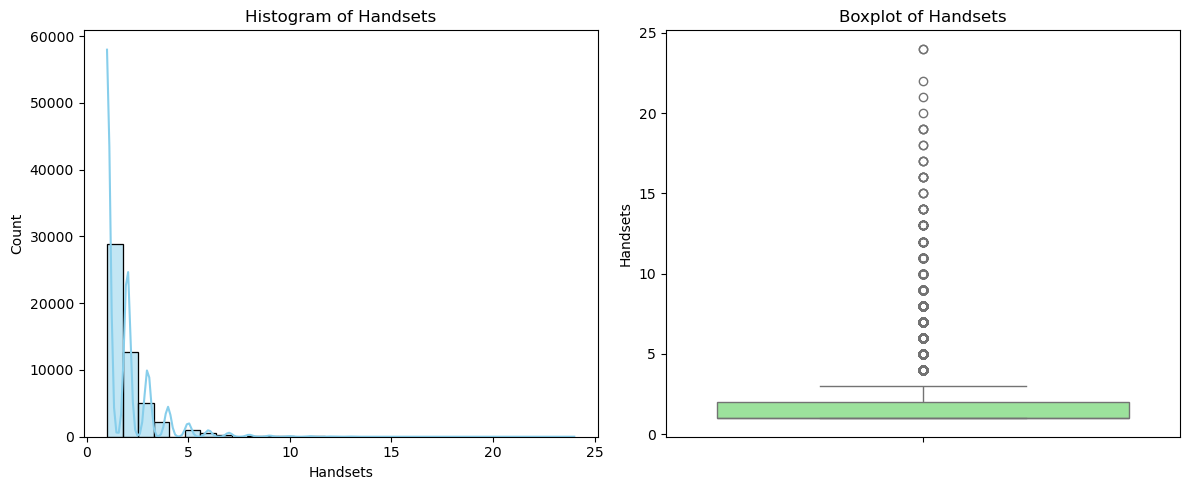

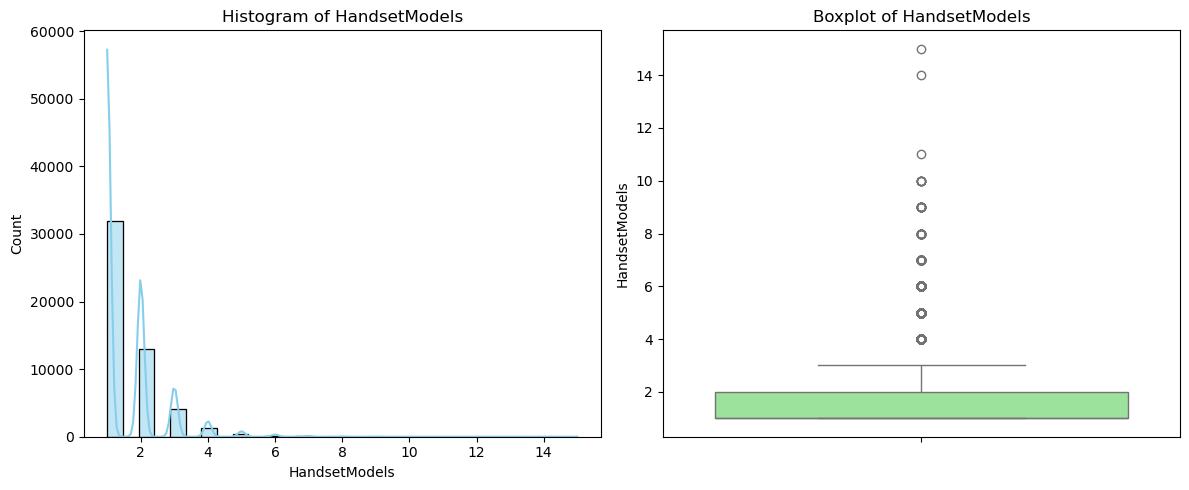

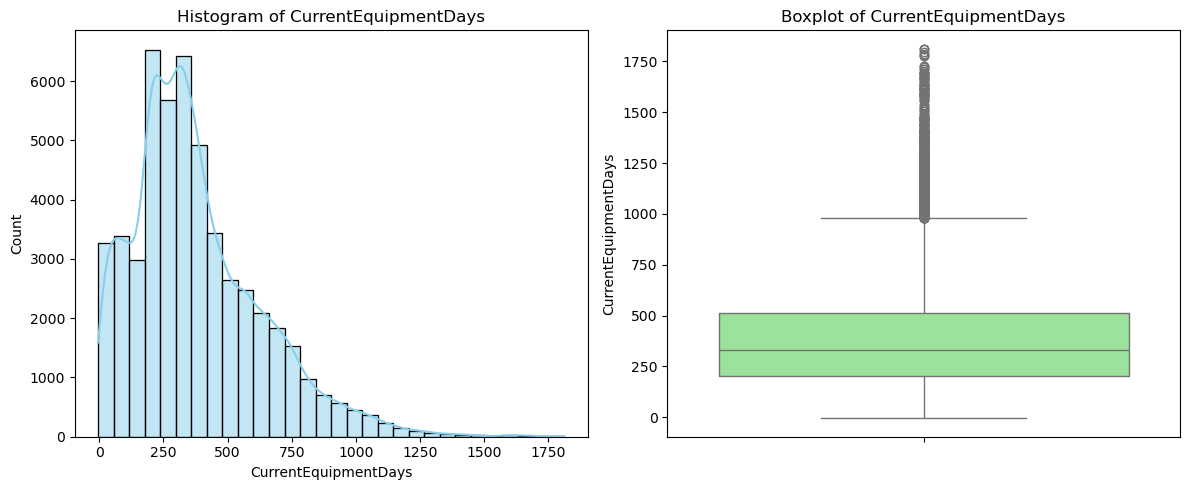

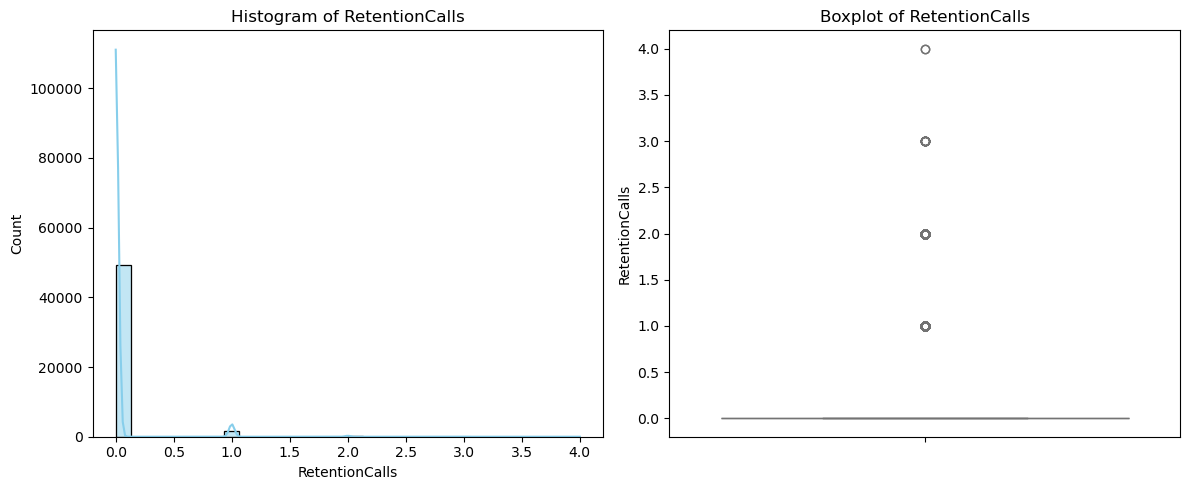

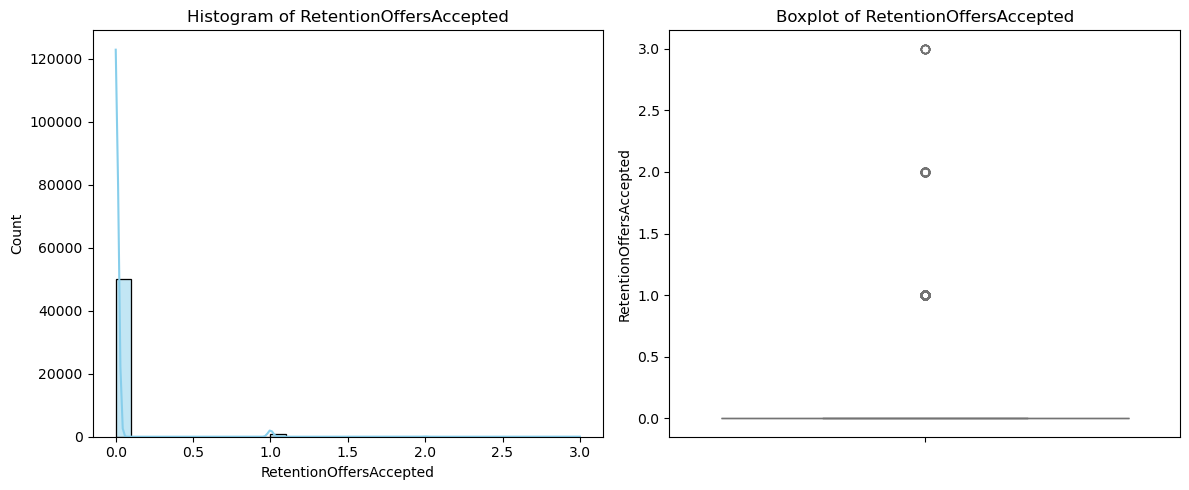

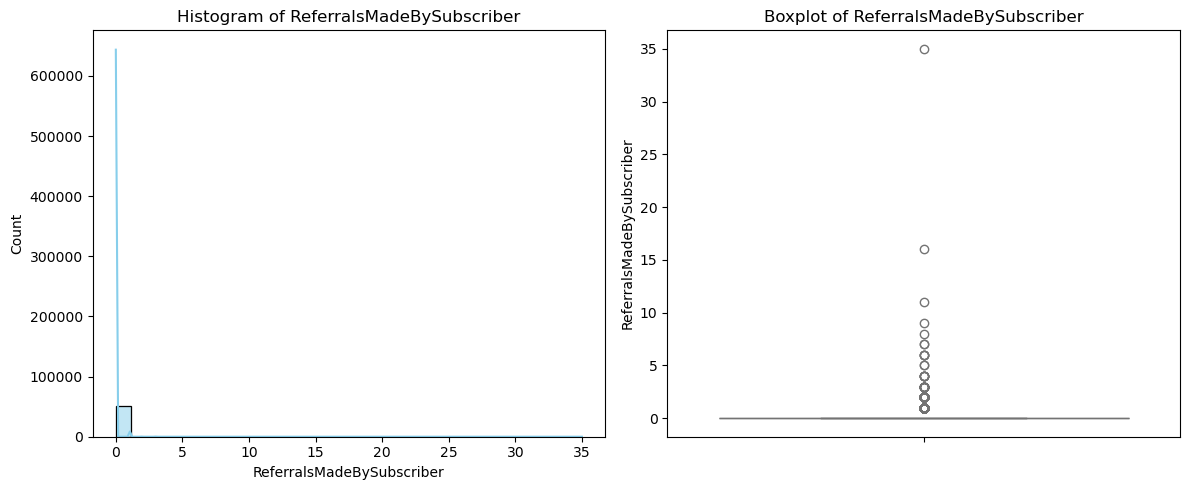

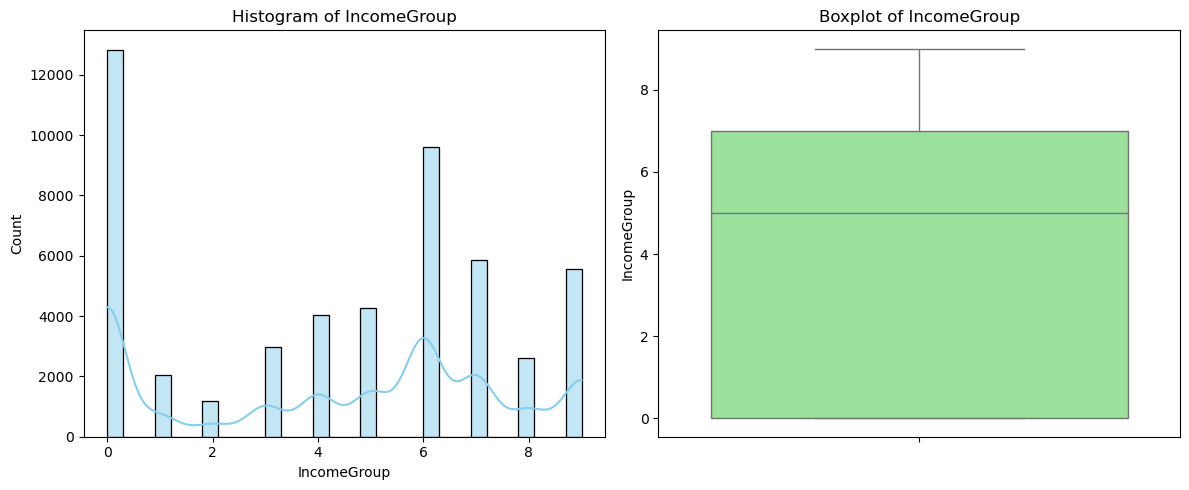

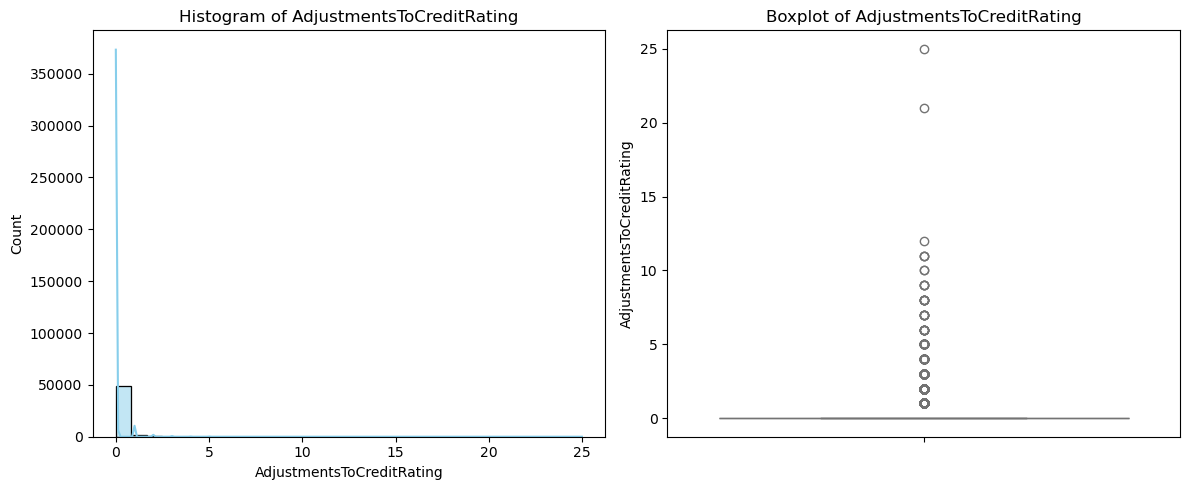

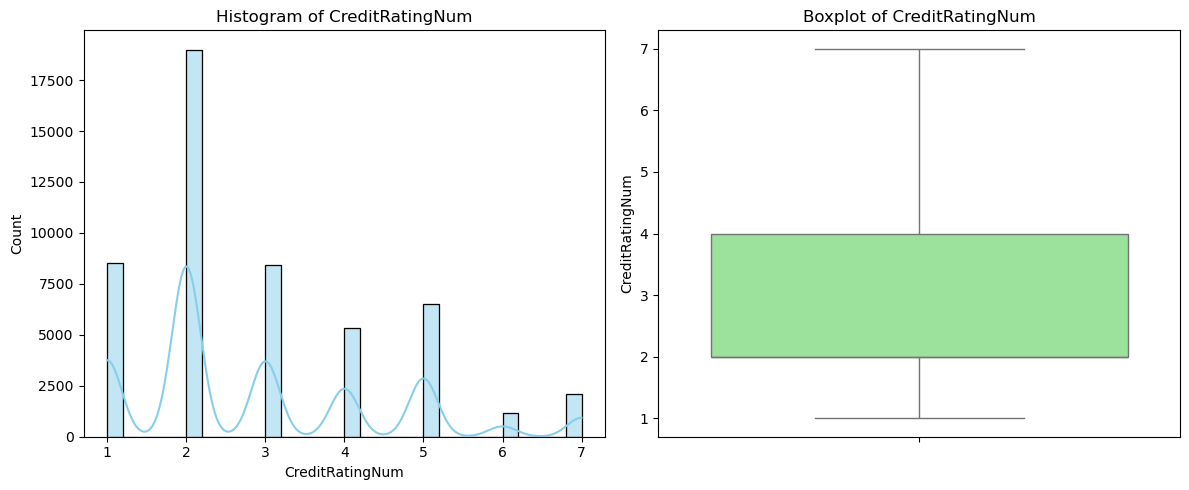

In [47]:
# Set figure size and layout
for col in numeric_cols.columns:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data_joined[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data_joined[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [48]:
corr_matrix = numeric_cols.corr()
corr_matrix

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,CreditRatingNum
MonthlyRevenue,1.000000,0.712968,0.629835,0.407372,0.787865,0.303638,-0.027429,-0.016571,0.429911,0.232162,0.449610,0.189039,0.200670,0.604635,0.494493,0.373571,0.640922,0.471562,0.416785,0.011413,0.468730,-0.002305,-0.014309,-0.041631,0.242457,0.235636,-0.217373,0.011142,0.015402,0.018933,-0.081593,0.034164,0.138478
MonthlyMinutes,0.712968,1.000000,0.584014,0.392377,0.571582,0.112722,-0.045172,-0.040720,0.593126,0.318009,0.645437,0.375658,0.288409,0.828031,0.693354,0.557527,0.770326,0.763910,0.572790,0.018664,0.614813,-0.068506,-0.029803,-0.065828,0.301769,0.291961,-0.310101,0.009560,0.014874,0.067452,-0.144348,0.045164,0.202249
TotalRecurringCharge,0.629835,0.584014,1.000000,0.311077,0.202951,0.073767,-0.016201,-0.025531,0.352390,0.178886,0.357709,0.152470,0.148592,0.480432,0.408444,0.306259,0.550819,0.367319,0.333693,0.014085,0.354574,-0.047954,-0.020661,-0.056717,0.233702,0.225111,-0.247995,-0.022028,-0.002306,0.036715,-0.077023,0.043396,0.131774
DirectorAssistedCalls,0.407372,0.392377,0.311077,1.000000,0.287366,0.070091,-0.026105,-0.016049,0.263450,0.139936,0.304613,0.093301,0.132401,0.280689,0.315140,0.186031,0.418529,0.273295,0.252728,0.002323,0.305112,0.017861,-0.002697,-0.014810,0.184442,0.172056,-0.121587,0.008477,0.013311,-0.001083,-0.017408,0.022424,0.075046
OverageMinutes,0.787865,0.571582,0.202951,0.287366,1.000000,0.064085,-0.028438,-0.018646,0.331685,0.190500,0.362670,0.137771,0.163859,0.515630,0.405672,0.319870,0.517877,0.390641,0.329256,0.003702,0.456640,0.001236,-0.002879,-0.012533,0.142617,0.143260,-0.124260,0.014811,0.009279,0.010081,-0.049999,0.020464,0.080810
RoamingCalls,0.303638,0.112722,0.073767,0.070091,0.064085,1.000000,-0.053853,-0.090723,0.068502,0.029203,0.039327,0.020460,0.024516,0.045897,0.045332,0.019837,0.062661,0.031633,0.060832,0.003243,0.035981,-0.010866,-0.003860,-0.003190,0.024343,0.022872,-0.029030,-0.002067,-0.000816,-0.006843,-0.015228,0.004398,0.016033
PercChangeMinutes,-0.027429,-0.045172,-0.016201,-0.026105,-0.028438,-0.053853,1.000000,0.609520,-0.081140,-0.055395,-0.086167,-0.039986,-0.028917,-0.106371,-0.063584,-0.070713,-0.109599,-0.089065,-0.087181,-0.004802,-0.129611,0.004182,0.001818,0.008530,-0.012484,-0.012226,-0.006066,-0.021080,-0.008200,-0.001986,0.011411,-0.004287,-0.032420
PercChangeRevenues,-0.016571,-0.040720,-0.025531,-0.016049,-0.018646,-0.090723,0.609520,1.000000,-0.037301,-0.033044,-0.055782,-0.032517,0.013148,-0.079493,-0.041648,-0.047406,-0.080709,-0.052559,-0.045741,-0.002365,-0.093950,-0.006877,0.002537,0.005136,-0.018092,-0.017872,0.005838,-0.019045,-0.012160,-0.001788,0.005717,-0.005517,-0.021146
DroppedCalls,0.429911,0.593126,0.352390,0.263450,0.331685,0.068502,-0.081140,-0.037301,1.000000,0.185124,0.543263,0.294747,0.264223,0.517854,0.564465,0.394289,0.574093,0.601072,0.715420,0.004301,0.396783,-0.046175,-0.021223,-0.049663,0.225186,0.217869,-0.216536,0.020308,0.014858,0.029546,-0.096316,0.031039,0.190854
BlockedCalls,0.232162,0.318009,0.178886,0.139936,0.190500,0.029203,-0.055395,-0.033044,0.185124,1.000000,0.255713,0.199638,0.262207,0.260401,0.230012,0.188910,0.301752,0.330684,0.816328,0.015123,0.286784,-0.072684,-0.016170,-0.026820,0.088458,0.085308,-0.124673,0.010841,0.008350,0.023848,-0.065375,0.004167,0.095268


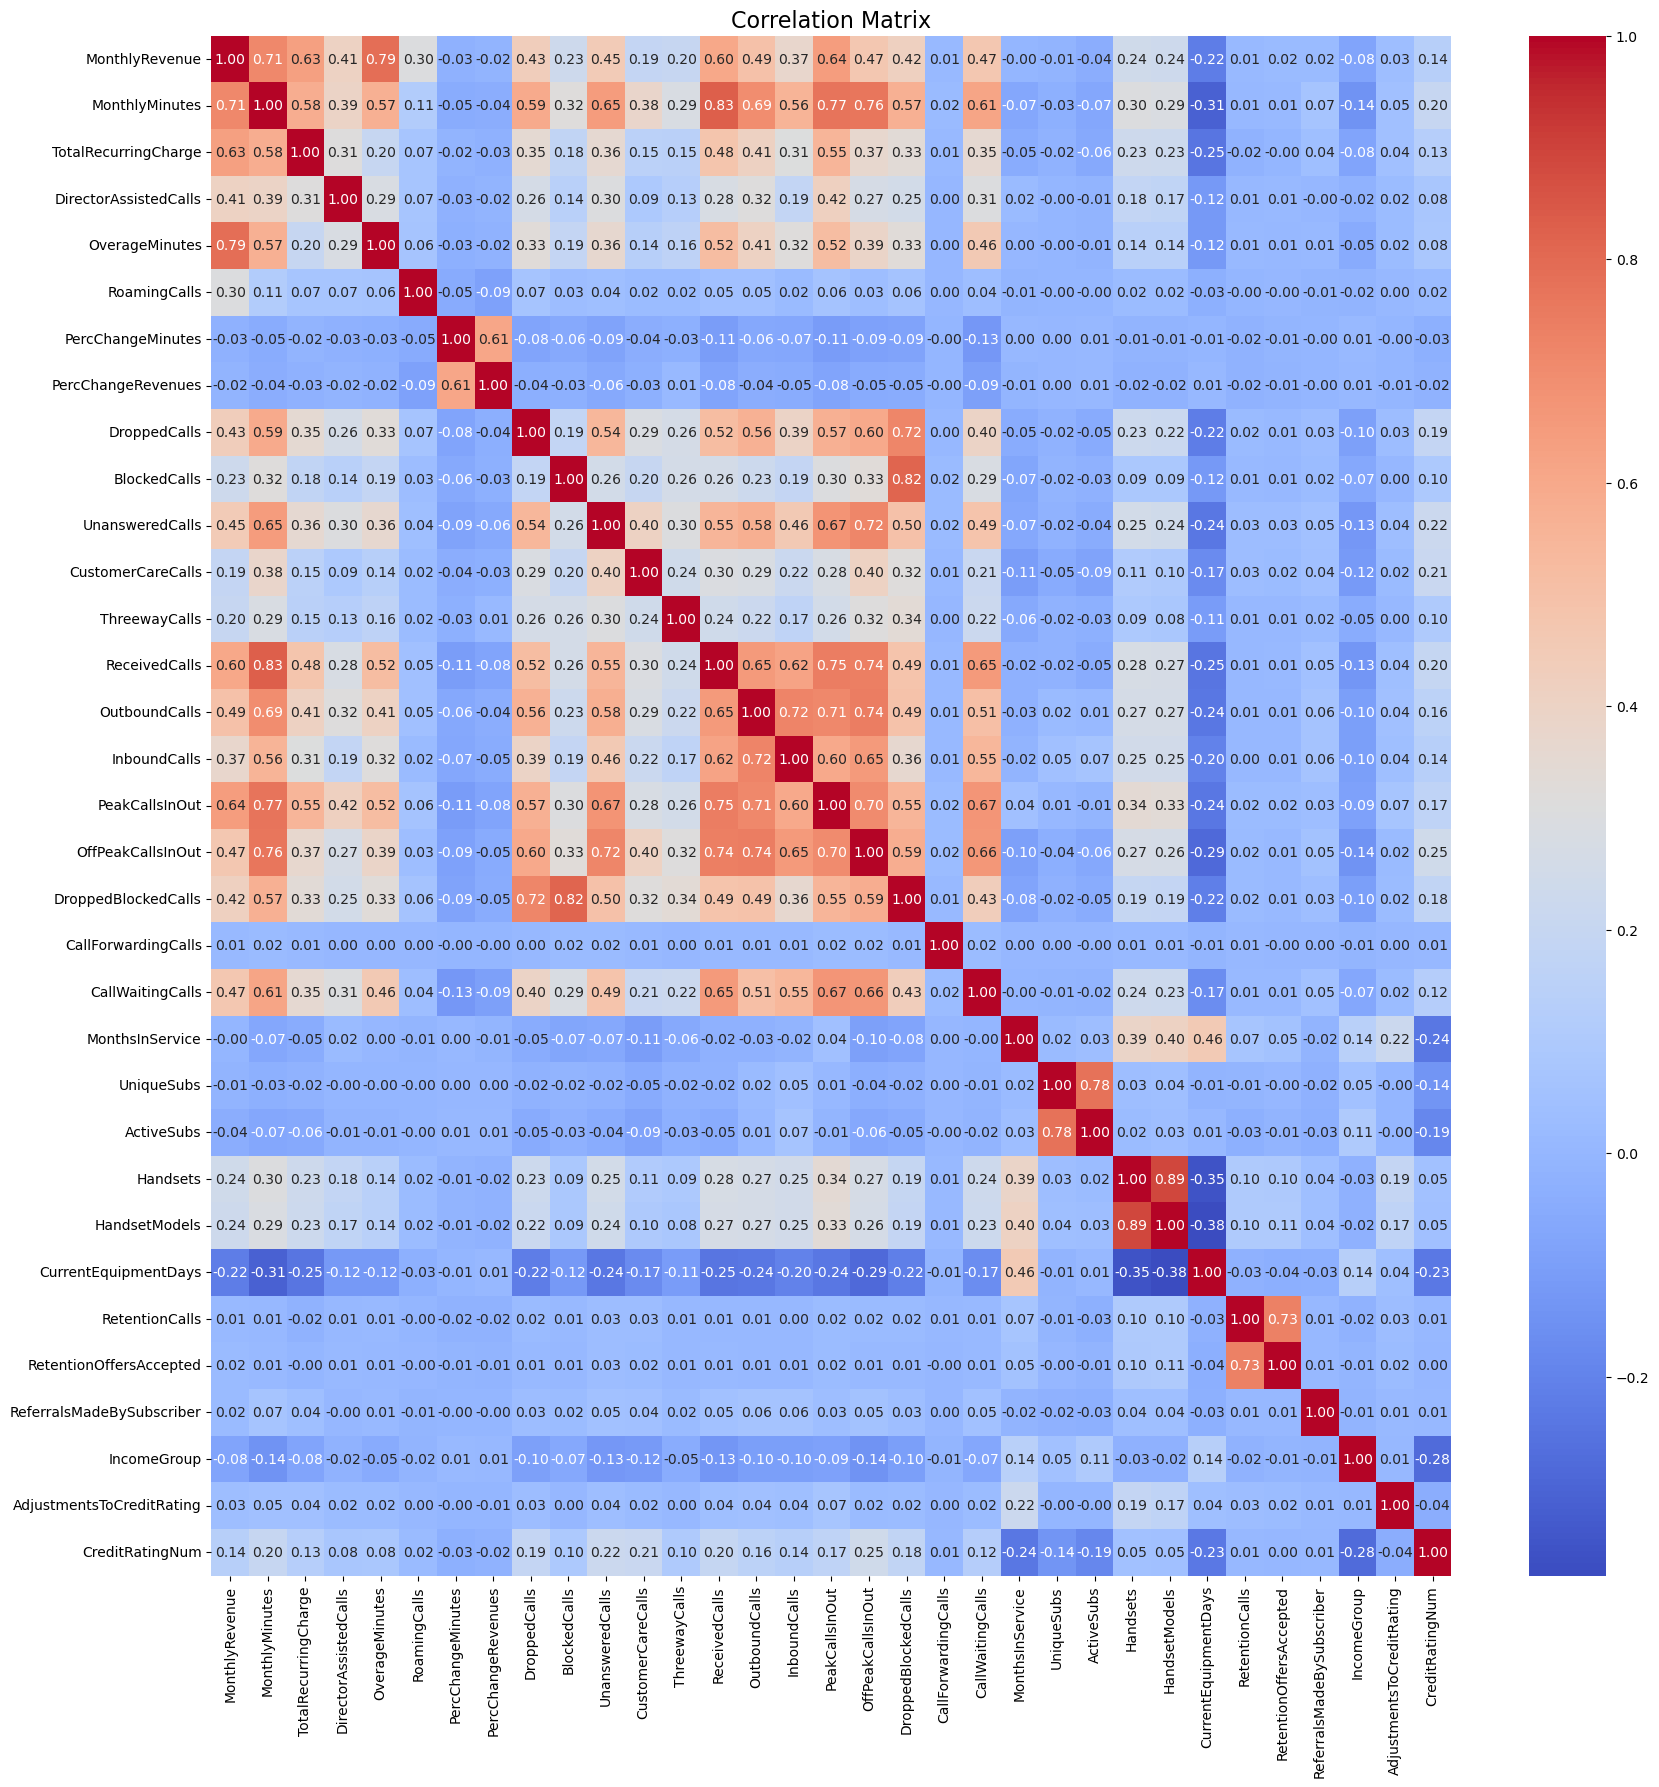

In [49]:
plt.figure(figsize=(20, 20))  # Adjust width and height as needed
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# FEATURE ENGINEERING

* Import neccessary libary

In [238]:
data_fe = data_joined.copy()
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,Suburban,Professional,No,1,Highest
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,Suburban,Professional,Yes,4,Medium
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,Town,Crafts,Yes,3,Good
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,Other,Other,No,4,Medium
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,Other,Professional,Yes,1,Highest


* Encoding Binary variables

In [239]:
non_binary_cols = ['CreditRatingLabel', 'PrizmCode', 'Occupation', 'MaritalStatus', 'ServiceArea', 'Homeownership', 'HandsetPrice']
non_binary_cols


['CreditRatingLabel',
 'PrizmCode',
 'Occupation',
 'MaritalStatus',
 'ServiceArea',
 'Homeownership',
 'HandsetPrice']

In [240]:
binary_col_names = list(data_fe.select_dtypes(include=['object']).columns)
binary_col_names

['Churn',
 'ServiceArea',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'HandsetPrice',
 'MadeCallToRetentionTeam',
 'PrizmCode',
 'Occupation',
 'MaritalStatus',
 'CreditRatingLabel']

In [241]:
data_fe['CreditRatingLabel'].unique()

array(['Highest', 'Medium', 'Good', 'VeryLow', 'High', 'Low', 'Lowest'],
      dtype=object)

In [61]:
mapping = {'No':0 , 'Yes':1}
binary_cols = []
for col in binary_col_names:
    if col not in non_binary_cols:
        binary_cols.append(col)

for name in binary_cols:
    data_fe[name] = data_fe[name].map(mapping)

data_fe["Homeownership"] = data_fe["Homeownership"].map({'Known':1, 'Unknown': 0})


In [242]:
binary_cols = [col for col in binary_col_names if col not in non_binary_cols]
data_fe[binary_cols] = data_fe[binary_cols].apply(lambda col: col.map(mapping))
data_fe["Homeownership"] = data_fe["Homeownership"].map({'Known': 1, 'Unknown': 0})
data_fe["CreditRatingLabel"] = data_fe["CreditRatingLabel"].map({'Lowest': 0,
                                                                 'VeryLow': 1,
                                                                 'Low': 2,
                                                                 'Medium': 3,
                                                                 'Good': 4,
                                                                 'High': 5,
                                                                 'Highest': 6})

In [243]:
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30,1,Suburban,Professional,No,1,6
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30,0,Suburban,Professional,Yes,4,3
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,Unknown,0,Town,Crafts,Yes,3,4
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10,0,Other,Other,No,4,3
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10,0,Other,Professional,Yes,1,6


* Adress 'Unknown' in HadsetPrice variable : Arounf 57% of the value is 'Unknown' hence we decided to drop this variable

In [244]:
# Count 'Unknown' values in HandsetPrice
unknown_count = data_fe['HandsetPrice'].value_counts().get('Unknown')
unknown_count

# Percentage of 'Unknown' values in HandsetPrice
unknown_percentage = (unknown_count / len(data_fe)) * 100
unknown_percentage

# Drop HandsetPrice variable
data_fe = data_fe.drop(columns=['HandsetPrice'])

In [245]:
data_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [246]:
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,PrizmCode,Occupation,MaritalStatus,CreditRatingNum,CreditRatingLabel
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,1,Suburban,Professional,No,1,6
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,0,Suburban,Professional,Yes,4,3
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,0,Town,Crafts,Yes,3,4
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,0,Other,Other,No,4,3
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,0,Other,Professional,Yes,1,6


### One Hot Coding
* One hot coding is applied to 'ServiceArea', 'PrizmCode', 'Occupation', 'MaritalStatus'

In [247]:
def ohe_cat(ColName, df):
    encoder = OneHotEncoder(sparse_output = False)
    encoded_cat = encoder.fit_transform(np.array(df[ColName]).reshape(-1,1))
    encoded_cat = pd.DataFrame(encoded_cat, columns = [f'{ColName}_{cat}' for cat in sorted(df[ColName].unique())])
    df = df.drop(ColName, axis = 'columns')
    df = pd.concat([df, encoded_cat], axis = 1)
    return df

##### Service Area

In [248]:
data_fe['ServiceArea'] = data_fe.ServiceArea.str[:3]
data_fe = ohe_cat('ServiceArea', data_fe)
data_fe.filter(like='ServiceArea')


,ServiceArea_AIR,ServiceArea_APC,ServiceArea_ATH,ServiceArea_ATL,ServiceArea_AWI,ServiceArea_BIR,ServiceArea_BOS,ServiceArea_CHI,ServiceArea_DAL,ServiceArea_DEN,ServiceArea_DET,ServiceArea_FLN,ServiceArea_GCW,ServiceArea_HAR,ServiceArea_HOP,ServiceArea_HOU,ServiceArea_HWI,ServiceArea_IND,ServiceArea_INH,ServiceArea_INU,ServiceArea_IPM,ServiceArea_KCY,ServiceArea_LAU,ServiceArea_LAW,ServiceArea_LAX,ServiceArea_LOU,ServiceArea_MIA,ServiceArea_MIL,ServiceArea_MIN,ServiceArea_NCR,ServiceArea_NEV,ServiceArea_NMC,ServiceArea_NMX,ServiceArea_NNY,ServiceArea_NOL,ServiceArea_NOR,ServiceArea_NSH,ServiceArea_NVU,ServiceArea_NYC,ServiceArea_OHH,ServiceArea_OHI,ServiceArea_OKC,ServiceArea_OMA,ServiceArea_PHI,ServiceArea_PHX,ServiceArea_PIT,ServiceArea_SAN,ServiceArea_SDA,ServiceArea_SEA,ServiceArea_SEW,ServiceArea_SFR,ServiceArea_SFU,ServiceArea_SHE,ServiceArea_SLC,ServiceArea_SLU,ServiceArea_STL,ServiceArea_VAH
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Prizm Code

In [249]:
data_fe = ohe_cat('PrizmCode', data_fe)
data_fe.filter(like='PrizmCode')

,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
51042,0.0,0.0,1.0,0.0
51043,1.0,0.0,0.0,0.0
51044,1.0,0.0,0.0,0.0
51045,1.0,0.0,0.0,0.0


##### Occupation

In [250]:
data_fe = ohe_cat('Occupation', data_fe)
data_fe.filter(like='Occupation')

,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
51042,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
51043,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
51044,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51045,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


##### Marital Status

In [251]:
data_fe = ohe_cat('MaritalStatus', data_fe)
data_fe.filter(like='MaritalStatus')

,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
51042,0.0,0.0,1.0
51043,1.0,0.0,0.0
51044,1.0,0.0,0.0
51045,1.0,0.0,0.0


In [252]:
# check for missing values
def check_missing(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending = False)
    if len(missing) > 0:
        print("Missing values found in the following columns:")
        print(missing)
    else:
        print("No missing values found.")
check_missing(data_fe)

No missing values found.


##### Selecting feature

In [253]:
X = data_fe.drop('Churn', axis='columns')
y = data_fe['Churn']
important = mutual_info_classif(X,y, random_state = 22)
important_feat = pd.Series(important, X.columns)
important_feat = important_feat.sort_values(ascending = False)

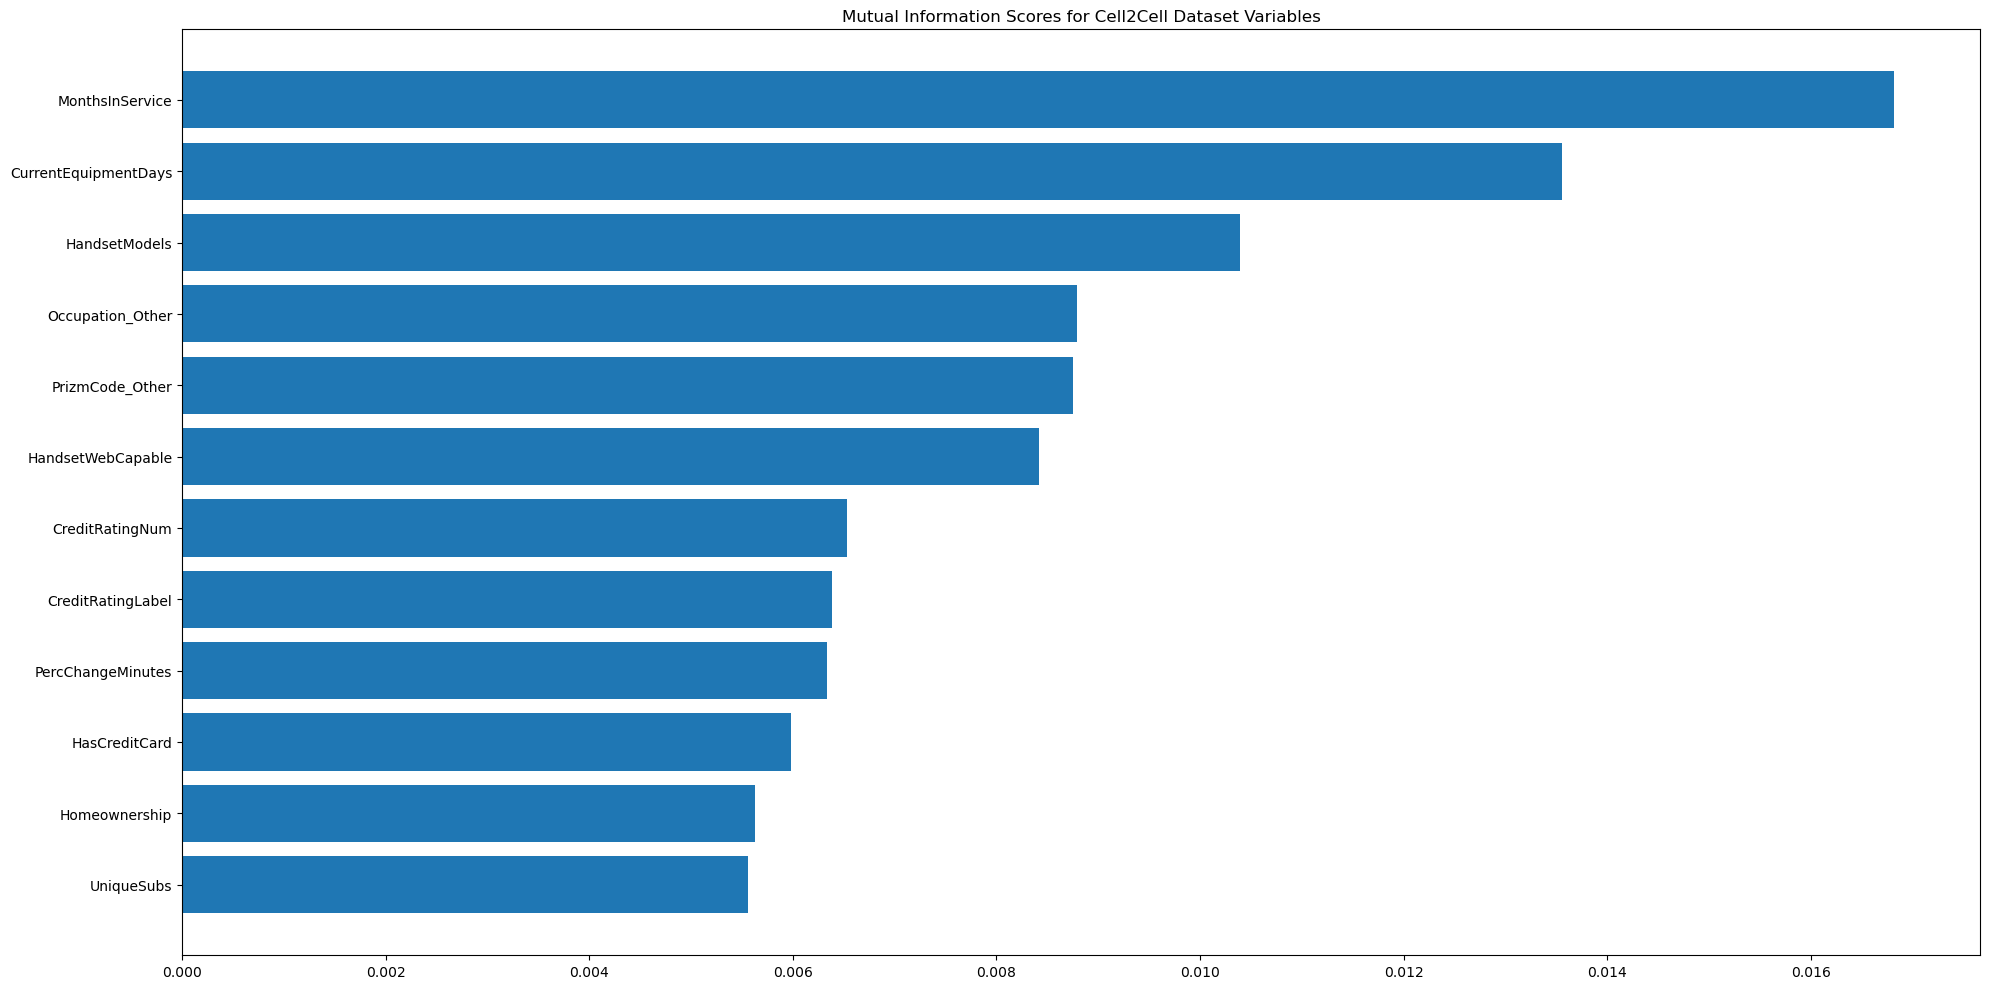

In [254]:
def plot_feat_importances(scores):
    scores = scores.sort_values(ascending=True)  # for horizontal bar plot
    width = np.arange(len(scores))
    ticks = list(scores.index)
    
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores for Cell2Cell Dataset Variables")
    plt.tight_layout()
    plt.savefig("Mutual_Information_Scores.jpeg")
    plt.show()

# 4. Plot only features with value > 0.005
plt.figure(dpi=100, figsize=(20, 10))
plot_feat_importances(important_feat[important_feat > 0.005])

##### Remove feature with high correlation

In [273]:
corr= data_fe.corr()

corr = corr[abs(corr) >= 0.7].dropna(how = 'all', axis = 0).dropna(how = 'all', axis = 1)
dropped_cols = []
# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
row_idx, col_idx = np.where(np.abs(matrix) >= 0.7)
# Print the highly correlated variable pairs
for i in range(len(row_idx)):
    row = corr.index[row_idx[i]]
    col = corr.columns[col_idx[i]]
    if row != col:
        # Compare two values and return the index of the minimum value
        min_idx = important_feat[[row,col]].idxmin()
        dropped_cols.append(min_idx)
dropped_cols

['CustomerID',
 'MonthlyRevenue',
 'OverageMinutes',
 'ReceivedCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'ActiveSubs',
 'Handsets',
 'Homeownership',
 'IncomeGroup',
 'BuysViaMailOrder',
 'IncomeGroup',
 'RetentionOffersAccepted',
 'RetentionCalls',
 'CreditRatingLabel',
 'Occupation_Professional']

#### Standardisation
* Standardise numerical values to mean 0 and sd 1 as we want to run Principal Component Analysis

In [274]:
data_fe.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRatingNum,CreditRatingLabel,ServiceArea_AIR,ServiceArea_APC,ServiceArea_ATH,ServiceArea_ATL,ServiceArea_AWI,ServiceArea_BIR,ServiceArea_BOS,ServiceArea_CHI,ServiceArea_DAL,ServiceArea_DEN,ServiceArea_DET,ServiceArea_FLN,ServiceArea_GCW,ServiceArea_HAR,ServiceArea_HOP,ServiceArea_HOU,ServiceArea_HWI,ServiceArea_IND,ServiceArea_INH,ServiceArea_INU,ServiceArea_IPM,ServiceArea_KCY,ServiceArea_LAU,ServiceArea_LAW,ServiceArea_LAX,ServiceArea_LOU,ServiceArea_MIA,ServiceArea_MIL,ServiceArea_MIN,ServiceArea_NCR,ServiceArea_NEV,ServiceArea_NMC,ServiceArea_NMX,ServiceArea_NNY,ServiceArea_NOL,ServiceArea_NOR,ServiceArea_NSH,ServiceArea_NVU,ServiceArea_NYC,ServiceArea_OHH,ServiceArea_OHI,ServiceArea_OKC,ServiceArea_OMA,ServiceArea_PHI,ServiceArea_PHX,ServiceArea_PIT,ServiceArea_SAN,ServiceArea_SDA,ServiceArea_SEA,ServiceArea_SEW,ServiceArea_SFR,ServiceArea_SFU,ServiceArea_SHE,ServiceArea_SLC,ServiceArea_SLU,ServiceArea_STL,ServiceArea_VAH,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,2.0,2.0,361.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,1,1,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,2.0,1.0,1504.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,0,4,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,1.0,1.0,1812.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,0,3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,9.0,4.0,458.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,0,4,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,4.0,3.0,852.0,0,0,

In [275]:
dropped_cols.append('Churn')

In [276]:
data_sd = data_fe.drop(columns = dropped_cols ,axis=1)
data_sd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Columns: 104 entries, MonthlyMinutes to MaritalStatus_Yes
dtypes: float64(85), int64(19)
memory usage: 40.5 MB


In [277]:
num_scale = StandardScaler()
data_scale = pd.DataFrame(num_scale.fit_transform(data_sd), 
                             columns = data_sd.columns, 
                             index = data_sd.index)

data_scale.describe()

,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,CustomerCareCalls,ThreewayCalls,OutboundCalls,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRatingNum,ServiceArea_AIR,ServiceArea_APC,ServiceArea_ATH,ServiceArea_ATL,ServiceArea_AWI,ServiceArea_BIR,ServiceArea_BOS,ServiceArea_CHI,ServiceArea_DAL,ServiceArea_DEN,ServiceArea_DET,ServiceArea_FLN,ServiceArea_GCW,ServiceArea_HAR,ServiceArea_HOP,ServiceArea_HOU,ServiceArea_HWI,ServiceArea_IND,ServiceArea_INH,ServiceArea_INU,ServiceArea_IPM,ServiceArea_KCY,ServiceArea_LAU,ServiceArea_LAW,ServiceArea_LAX,ServiceArea_LOU,ServiceArea_MIA,ServiceArea_MIL,ServiceArea_MIN,ServiceArea_NCR,ServiceArea_NEV,ServiceArea_NMC,ServiceArea_NMX,ServiceArea_NNY,ServiceArea_NOL,ServiceArea_NOR,ServiceArea_NSH,ServiceArea_NVU,ServiceArea_NYC,ServiceArea_OHH,ServiceArea_OHI,ServiceArea_OKC,ServiceArea_OMA,ServiceArea_PHI,ServiceArea_PHX,ServiceArea_PIT,ServiceArea_SAN,ServiceArea_SDA,ServiceArea_SEA,ServiceArea_SEW,ServiceArea_SFR,ServiceArea_SFU,ServiceArea_SHE,ServiceArea_SLC,ServiceArea_SLU,ServiceArea_STL,ServiceArea_VAH,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
count,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04,5.104700e+04
mean,9.520858e-17,-8.574340e-17,1.280583e-17,-5.010978e-18,5.289365e-18,4.732590e-18,-5.010978e-18,1.391938e-17,3.034425e-17,-1.893036e-17,-1.948714e-18,-3.006587e-17,-1.781681e-17,-1.057873e-17,9.799246e-17,3.674717e-17,1.057873e-17,8.073242e-18,-2.561166e-17,-1.558971e-17,-3.340652e-18,-1.163660e-16,-3.062264e-18,-2.923070e-17,-1.906955e-17,1.219338e-16,-7.126724e-17,7.015369e-17,-7.238079e-18,3.117942e-17,5.567753e-17,-6.625626e-17,3.674717e-17,3.702556e-17,1.113551e-17,-2.011351e-17,6.013173e-17,1.447616e-17,6.820498e-18,-4.565558e-17,3.229297e-17,1.113551e-17,2.004391e-17,-5.178010e-17,-5.122333e-17,4.454203e-18,2.449811e-17,4.175815e-19,4.621235e-17,2.004391e-17,2.505489e-17,6.542110e-18,1.113551e-18,-1.781681e-17,5.233688e-17,4.523799e-18,4.454203e-18,-9.799246e-17,2.561166e-17,-3.340652e-17,5.066655e-17,4.788268e-17,-2.672522e-17,-7.572144e-17,9.882762e-18,-3.396329e-17,2.338456e-17,3.173619e-1

In [278]:
df_standardise = pd.DataFrame(normalize(data_scale), 
                             columns = data_scale.columns,
                             index = data_scale.index)
df_standardise.describe()

,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,CustomerCareCalls,ThreewayCalls,OutboundCalls,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRatingNum,ServiceArea_AIR,ServiceArea_APC,ServiceArea_ATH,ServiceArea_ATL,ServiceArea_AWI,ServiceArea_BIR,ServiceArea_BOS,ServiceArea_CHI,ServiceArea_DAL,ServiceArea_DEN,ServiceArea_DET,ServiceArea_FLN,ServiceArea_GCW,ServiceArea_HAR,ServiceArea_HOP,ServiceArea_HOU,ServiceArea_HWI,ServiceArea_IND,ServiceArea_INH,ServiceArea_INU,ServiceArea_IPM,ServiceArea_KCY,ServiceArea_LAU,ServiceArea_LAW,ServiceArea_LAX,ServiceArea_LOU,ServiceArea_MIA,ServiceArea_MIL,ServiceArea_MIN,ServiceArea_NCR,ServiceArea_NEV,ServiceArea_NMC,ServiceArea_NMX,ServiceArea_NNY,ServiceArea_NOL,ServiceArea_NOR,ServiceArea_NSH,ServiceArea_NVU,ServiceArea_NYC,ServiceArea_OHH,ServiceArea_OHI,ServiceArea_OKC,ServiceArea_OMA,ServiceArea_PHI,ServiceArea_PHX,ServiceArea_PIT,ServiceArea_SAN,ServiceArea_SDA,ServiceArea_SEA,ServiceArea_SEW,ServiceArea_SFR,ServiceArea_SFU,ServiceArea_SHE,ServiceArea_SLC,ServiceArea_SLU,ServiceArea_STL,ServiceArea_VAH,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
count,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,-0.006938,-0.003701,-0.004342,-0.003143,0.000913,-0.000065,-0.004670,-0.004482,-0.004777,-0.006361,-0.001601,-0.007591,-0.003355,-0.001576,-0.004706,0.000262,-0.005823,-0.003266,0.003443,-0.007536,-0.005971,-0.006794,-0.005111,-0.005111,-0.006439,-0.003442,-0.001865,-0.004128,-0.002985,-0.005490,-0.004320,-0.004323,0.001105,-0.003507,0.003770,-0.002387,0.000775,-0.003301,-0.003725,0.000308,0.001566,0.001938,-0.003305,-0.000979,0.000715,-0.002641,-0.002258,-0.000528,0.000104,-0.004198,-0.003946,-0.003371,-0.000735,-0.002785,-0.002517,-0.003047,-0.000735,0.007394,-0.004153,0.000431,-0.003895,-0.003243,0.000479,0.000226,-0.001829,-0.002973,-0.003589,-0.004280,-0.003118,-0.004187,-0.002252,0.012909,-0.003955,-0.000179,-0.003605,-0.003976,-0.001181,-0.003365,-0.004240,0.000606,-0.002448,-0.001866,-0.003210,0.005132,-0.001392,-0.003885,-0.004058,-0.000528,-0.002890,-0.002745,0.006844,-0.006044,-0.000468

In [279]:
data_scale['Churn'] = data_fe['Churn']
data_scale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Columns: 105 entries, MonthlyMinutes to Churn
dtypes: float64(104), int64(1)
memory usage: 40.9 MB


In [280]:
df_standardise["Churn"] = data_fe["Churn"]
df_standardise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Columns: 105 entries, MonthlyMinutes to Churn
dtypes: float64(104), int64(1)
memory usage: 40.9 MB


#### Principle Component Analysis

In [281]:
y = df_standardise["Churn"].copy()
X = df_standardise.drop("Churn", axis=1).copy()
X.shape

(51047, 104)

In [282]:
pca = PCA()
pca.fit(X)
var_exp = pca.explained_variance_ratio_
var_exp.shape

(104,)

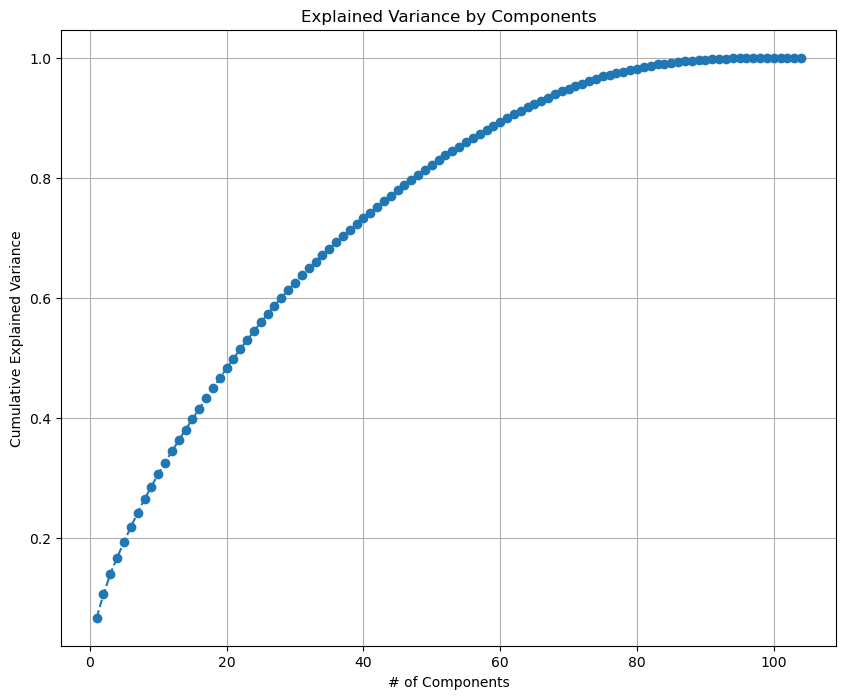

In [283]:
plt.figure(figsize = (10, 8))
plt.plot(range(1, 105), var_exp.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel("# of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()

#plt.savefig("Explained Variance by Components.jpeg")
plt.show()

In [289]:
pca = PCA(n_components = 50)
pca.fit(X)
var_exp = pca.explained_variance_ratio_
var_exp.shape

(50,)

In [290]:
comp_indecies = ["Component" + str(i) for i in range(1, 51)]

df_pca_comp = pd.DataFrame(data = pca.components_,
                          columns = X.columns.values,
                           index = comp_indecies)

df_pca_comp

,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,CustomerCareCalls,ThreewayCalls,OutboundCalls,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,HandsetModels,CurrentEquipmentDays,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRatingNum,ServiceArea_AIR,ServiceArea_APC,ServiceArea_ATH,ServiceArea_ATL,ServiceArea_AWI,ServiceArea_BIR,ServiceArea_BOS,ServiceArea_CHI,ServiceArea_DAL,ServiceArea_DEN,ServiceArea_DET,ServiceArea_FLN,ServiceArea_GCW,ServiceArea_HAR,ServiceArea_HOP,ServiceArea_HOU,ServiceArea_HWI,ServiceArea_IND,ServiceArea_INH,ServiceArea_INU,ServiceArea_IPM,ServiceArea_KCY,ServiceArea_LAU,ServiceArea_LAW,ServiceArea_LAX,ServiceArea_LOU,ServiceArea_MIA,ServiceArea_MIL,ServiceArea_MIN,ServiceArea_NCR,ServiceArea_NEV,ServiceArea_NMC,ServiceArea_NMX,ServiceArea_NNY,ServiceArea_NOL,ServiceArea_NOR,ServiceArea_NSH,ServiceArea_NVU,ServiceArea_NYC,ServiceArea_OHH,ServiceArea_OHI,ServiceArea_OKC,ServiceArea_OMA,ServiceArea_PHI,ServiceArea_PHX,ServiceArea_PIT,ServiceArea_SAN,ServiceArea_SDA,ServiceArea_SEA,ServiceArea_SEW,ServiceArea_SFR,ServiceArea_SFU,ServiceArea_SHE,ServiceArea_SLC,ServiceArea_SLU,ServiceArea_STL,ServiceArea_VAH,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
Component1,0.134551,0.100593,0.040939,0.003383,-0.008201,-0.007768,0.079459,0.041132,0.118816,0.089288,-0.000185,0.043228,-0.108478,-0.040220,0.041345,-0.139178,-0.254548,0.010701,0.078455,-0.203888,-0.135196,-0.326006,-0.029450,-0.114478,-0.239799,-0.339428,0.001503,-0.027205,0.002355,-0.029216,-0.009805,-0.000748,0.199927,0.003365,0.006504,-0.001271,-0.012985,-0.002281,-0.003037,-0.001911,-0.001371,-0.048059,-0.012793,-0.030927,-0.022514,-0.001508,-0.012954,-0.000201,-0.014137,-0.002221,-0.010612,-0.002354,-0.000289,-0.001515,-0.023983,-0.001401,-0.000280,0.053644,-0.014712,-0.013916,-0.010114,-0.022199,0.000902,-0.001853,-8.495632e-04,-0.002992,-0.017095,-0.008062,-0.002044,-0.008827,-0.001064,0.144472,-0.004573,-0.050120,-0.007355,-0.012164,-0.006523,-0.016390,-0.007498,-0.030335,-0.001372,-0.008444,-0.002088,0.046420,-0.000615,-0.003827,-0.004804,-0.000206,-0.018931,-0.001380,0.215178,-0.040017,-0.138527,-0.096554,-0.038226,-0.059681,-0.006918,0.263080,-0.037245,-0.043630,-0.013974,-0.009990,0.353667,-0.348575
Component2,0.415577,0.331735,0.181164,0.031138,-0.034350,-0.031864,0.189134,0.119089,0.351334,0.307397,0.004969,0.232431,-0.056871,0.005509,0.261364,-0.310578,0.116914,0.134003,0.136179,0.121104,0.089341,0.086766,0.007702,0.033643,0.066637,0.075382,0.016576,0.055971,0.037925,0.023195,0.025005,0.027152,0.118677,0.024134,-0.019962,0.002255,0.029020,0.004230,0.005691,-0.013411,0.025748,0.027100,0.004873,0.043197,0.011264,0.002640,0.004903,0.000334,0.043861,0.007787,0.009023,0.004172,0.000483,0.002891,0.007799,0.003950,0.000493,-0.081749,0.010628,0.022828,0.015455,0.006716,0.023350,-0.031610,1.514452e-03,0.020549,0.011266,0.015984,0.003301,0.013378,0.001979,-0.102148,0.006910,0.020153,0.007727,0.010613,0.016808,0.013262,0.008072,0.060511,0.002109,-0.004387,0.003307,-0.092263,0.000970,0.005056,0.005646,0.000335,0.017340,0.002847,-0.072436,0.032530,0.030093,0.042811,0.020626,0.040290,0.006198,-0.079934,0.008623,0.026386,0.013740,0.028599,-0.105076,0.080555
Component3,0.014320,-0.006195,-0.014321,-0.006823,0.014154,0.005343,0.017659,0.026943,0.055472,0.001277,-0.001997,-0.034223,0.056960,-0.023824,0.069100,-0.016939,0.038753,-0.000720,0.020968,-0.007473,-0.003723,0.104989,-0.005326,0.050587,0.039535,0.240515,0.092666,-0.003089,-0

In [291]:
scores_pca = pca.transform(X)
scores_pca.shape

(51047, 50)

In [292]:
df_pca = pd.DataFrame({})

In [293]:
df_pca = pd.DataFrame(data = scores_pca, columns = comp_indecies)
df_pca["Churn"] = df_standardise["Churn"]
df_pca.reset_index(drop = True, inplace = True)
df_pca.shape

(51047, 51)